In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import matplotlib as mpl
import seaborn as sns
import networkx as nx
from matplotlib.ticker import FuncFormatter
from scipy import stats
from math import radians, cos, sin, asin, sqrt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:,.2f}".format)

BASE_PATH  = r"C:\Storage\Documents\Kuliah\competition\ASA DATAFEST\2026-ASA-DataFest-Data-Files\2026-ASA-DataFest-Data-Files"
OUTPUT_DIR = "./plots_story"
os.makedirs(OUTPUT_DIR, exist_ok=True)

SVH_LAT, SVH_LON = 39.0558, -95.6890

C_ED, C_OUT, C_WARN, C_OK = "#E63946", "#457B9D", "#F4A261", "#2A9D8F"
C_PURPLE, C_BG, C_GRID    = "#6A4C93", "#F8F9FA", "#DEE2E6"
C_SOFT_BLUE = "#a2d2ff"
C_HIGHLIGHT = "#e63946"
C_LIGHT_BLUE = "#caf0f8"
PALETTE = [C_ED, C_OUT, C_WARN, C_OK, C_PURPLE, "#1982C4"]

# PPT-optimised global style: large fonts, clean background, high contrast
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.grid": False,
    "font.family": "DejaVu Sans",
    "axes.titlesize": 18, "axes.labelsize": 15,
    "xtick.labelsize": 13, "ytick.labelsize": 13,
    "legend.fontsize": 13, "figure.dpi": 150,
    "text.color": "#1a1a1a",
    "axes.labelcolor": "#1a1a1a",
    "xtick.color": "#1a1a1a",
    "ytick.color": "#1a1a1a",
    "axes.titlecolor": "#1a1a1a",
    "axes.edgecolor": "#cccccc",
    "axes.linewidth": 1.2,
})

def pct_fmt(x, _): return f"{x:.0f}%"

def savefig(fig, name):
    fig.savefig(os.path.join(OUTPUT_DIR, f"{name}.png"), bbox_inches="tight",
                dpi=180, facecolor="white")
    plt.show()

def haversine(lon1, lat1, lon2, lat2):
    if any(pd.isna([lon1, lat1, lon2, lat2])): return np.nan
    try:
        lon1,lat1,lon2,lat2 = map(radians,[float(lon1),float(lat1),float(lon2),float(lat2)])
        dlon, dlat = lon2-lon1, lat2-lat1
        a = sin(dlat/2)**2 + cos(lat1)*cos(lat2)*sin(dlon/2)**2
        return 2*asin(sqrt(a))*6371
    except: return np.nan


In [2]:
def load_csv(fname):
    path = os.path.join(BASE_PATH, fname)
    df = pd.read_csv(path, low_memory=False)
    return df

enc  = load_csv("encounters.csv")
pat  = load_csv("patients.csv")
soc  = load_csv("social_determinants.csv")
diag = load_csv("diagnosis.csv")
dept = load_csv("departments.csv")
prov = load_csv("providers.csv")
try:
    tiger    = load_csv("tigercensuscodes.csv")
    HAS_TIGER = True
except FileNotFoundError:
    HAS_TIGER = False


In [3]:
# Boolean flags
for col in ["IsEdVisit","IsHospitalAdmission","IsHospitalOutpatientVisit",
            "IsInpatientAdmission","IsObservation","IsOutpatientFaceToFaceVisit"]:
    if col in enc.columns:
        enc[col] = enc[col].astype(str).str.strip().str.lower().isin(["true","1","yes"])

enc["Date"]     = pd.to_datetime(enc["Date"], errors="coerce")
enc             = enc.sort_values(["PatientDurableKey","Date"])

# ── Social determinant flags per DISEASE JOURNEY ────────────────────────────
# Unit analisis: (PatientDurableKey, DiagnosisValue) = satu journey penyakit.
#
# Definisi barrier (LEBIH KETAT — hanya jawaban yang jelas mengindikasikan barrier):
#   Transportation Needs / Financial / Housing / Food → "Yes" atau "Already shut off"
#   Tidak include "sometimes", "a little hard" karena ambigu dan inflate angka

BARRIER_ANSWERS = ["yes", "already shut off"]

DOMAINS = ["Transportation Needs","Financial Resource Strain","Housing Stability","Food Insecurity"]

# Filter hanya jawaban yang jelas barrier
soc_positive = soc[
    soc["Domain"].isin(DOMAINS) &
    soc["AnswerText"].astype(str).str.strip().str.lower().isin(BARRIER_ANSWERS)
].copy()

# Gabungkan ke encounters untuk dapat DiagnosisValue (journey key)
enc_diag = enc[["EncounterKey","PatientDurableKey","PrimaryDiagnosisKey"]].merge(
    diag[["DiagnosisKey","DiagnosisValue"]],
    left_on="PrimaryDiagnosisKey", right_on="DiagnosisKey", how="left"
)

soc_journey = soc_positive.merge(
    enc_diag[["EncounterKey","PatientDurableKey","DiagnosisValue"]],
    on=["EncounterKey","PatientDurableKey"], how="left"
)

# Flag domain per journey (PatientDurableKey + DiagnosisValue)
soc_flags = (
    soc_journey
    .groupby(["PatientDurableKey","DiagnosisValue","Domain"]).size()
    .unstack(fill_value=0).clip(upper=1).astype(bool).reset_index()
)
for d in DOMAINS:
    if d not in soc_flags.columns: soc_flags[d] = False

soc_flags["Both"]        = soc_flags["Transportation Needs"] & soc_flags["Financial Resource Strain"]
soc_flags["TransOnly"]   = soc_flags["Transportation Needs"] & ~soc_flags["Financial Resource Strain"]
soc_flags["FinOnly"]     = ~soc_flags["Transportation Needs"] &  soc_flags["Financial Resource Strain"]
soc_flags["Neither"]     = ~soc_flags["Transportation Needs"] & ~soc_flags["Financial Resource Strain"]
soc_flags["Any_Barrier"] = soc_flags["Transportation Needs"] | soc_flags["Financial Resource Strain"]

def label_barrier(row):
    if row["Both"]:      return "Both Barriers"
    if row["FinOnly"]:   return "Financial Only"
    if row["TransOnly"]: return "Transport Only"
    return "No Barrier"
soc_flags["Barrier_Group"] = soc_flags.apply(label_barrier, axis=1)

# ── Master table: join ke encounters via journey key ─────────────────────────
# enc sudah punya PrimaryDiagnosisKey; tambah DiagnosisValue dulu
enc = enc.merge(
    diag[["DiagnosisKey","DiagnosisValue"]],
    left_on="PrimaryDiagnosisKey", right_on="DiagnosisKey", how="left"
)

# ── GapDays: dihitung per JOURNEY (patient + diagnosis), bukan per pasien ──
# Ini sesuai definisi journey: encounter yang dihubungkan oleh diagnosis sama
enc = enc.sort_values(["PatientDurableKey","DiagnosisValue","Date"])
enc["PrevDate"] = enc.groupby(["PatientDurableKey","DiagnosisValue"])["Date"].shift(1)
enc["GapDays"]  = (enc["Date"] - enc["PrevDate"]).dt.days

master = enc.merge(pat, left_on="PatientDurableKey", right_on="DurableKey", how="left")
master = master.merge(
    soc_flags[["PatientDurableKey","DiagnosisValue"] + DOMAINS +
              ["Both","TransOnly","FinOnly","Neither","Any_Barrier","Barrier_Group"]],
    on=["PatientDurableKey","DiagnosisValue"], how="left"
)
for d in DOMAINS: master[d] = master[d].fillna(False)
master["Any_Barrier"]   = master["Any_Barrier"].fillna(False)
master["Barrier_Group"] = master["Barrier_Group"].fillna("No Barrier")

# MyChart table
visit_cnt = enc.groupby("PatientDurableKey").size().reset_index(name="VisitCount")
pat_mc    = pat.merge(visit_cnt, left_on="DurableKey", right_on="PatientDurableKey", how="left")
pat_mc["VisitCount"] = pat_mc["VisitCount"].fillna(0)
pat_mc["MyChartStatus"] = pat_mc["MyChartStatus"].astype(str).str.strip()

COL_MC = {
    "Activated":       C_OK,
    "Patient Declined":C_ED,
    "Inactivated":     C_PURPLE,
    "Not Invited":     C_OUT,
    "Other":           "#888"
}

print(f"Surveyed (any barrier): {soc_flags['Any_Barrier'].sum():,} journeys")
print(f"Transport Only:         {soc_flags['TransOnly'].sum():,} journeys")
print(f"Financial Only:         {soc_flags['FinOnly'].sum():,} journeys")
print(f"Both Barriers:          {soc_flags['Both'].sum():,} journeys")

Surveyed (any barrier): 4,709 journeys
Transport Only:         1,158 journeys
Financial Only:         2,172 journeys
Both Barriers:          1,379 journeys


---

# System Portrait

> *"Before asking who is at fault, we need to understand: how large is the problem?"*

This section establishes a baseline : 
- how many ED visits occur
- what the distribution looks like
- and which social domains are reported most by patients.


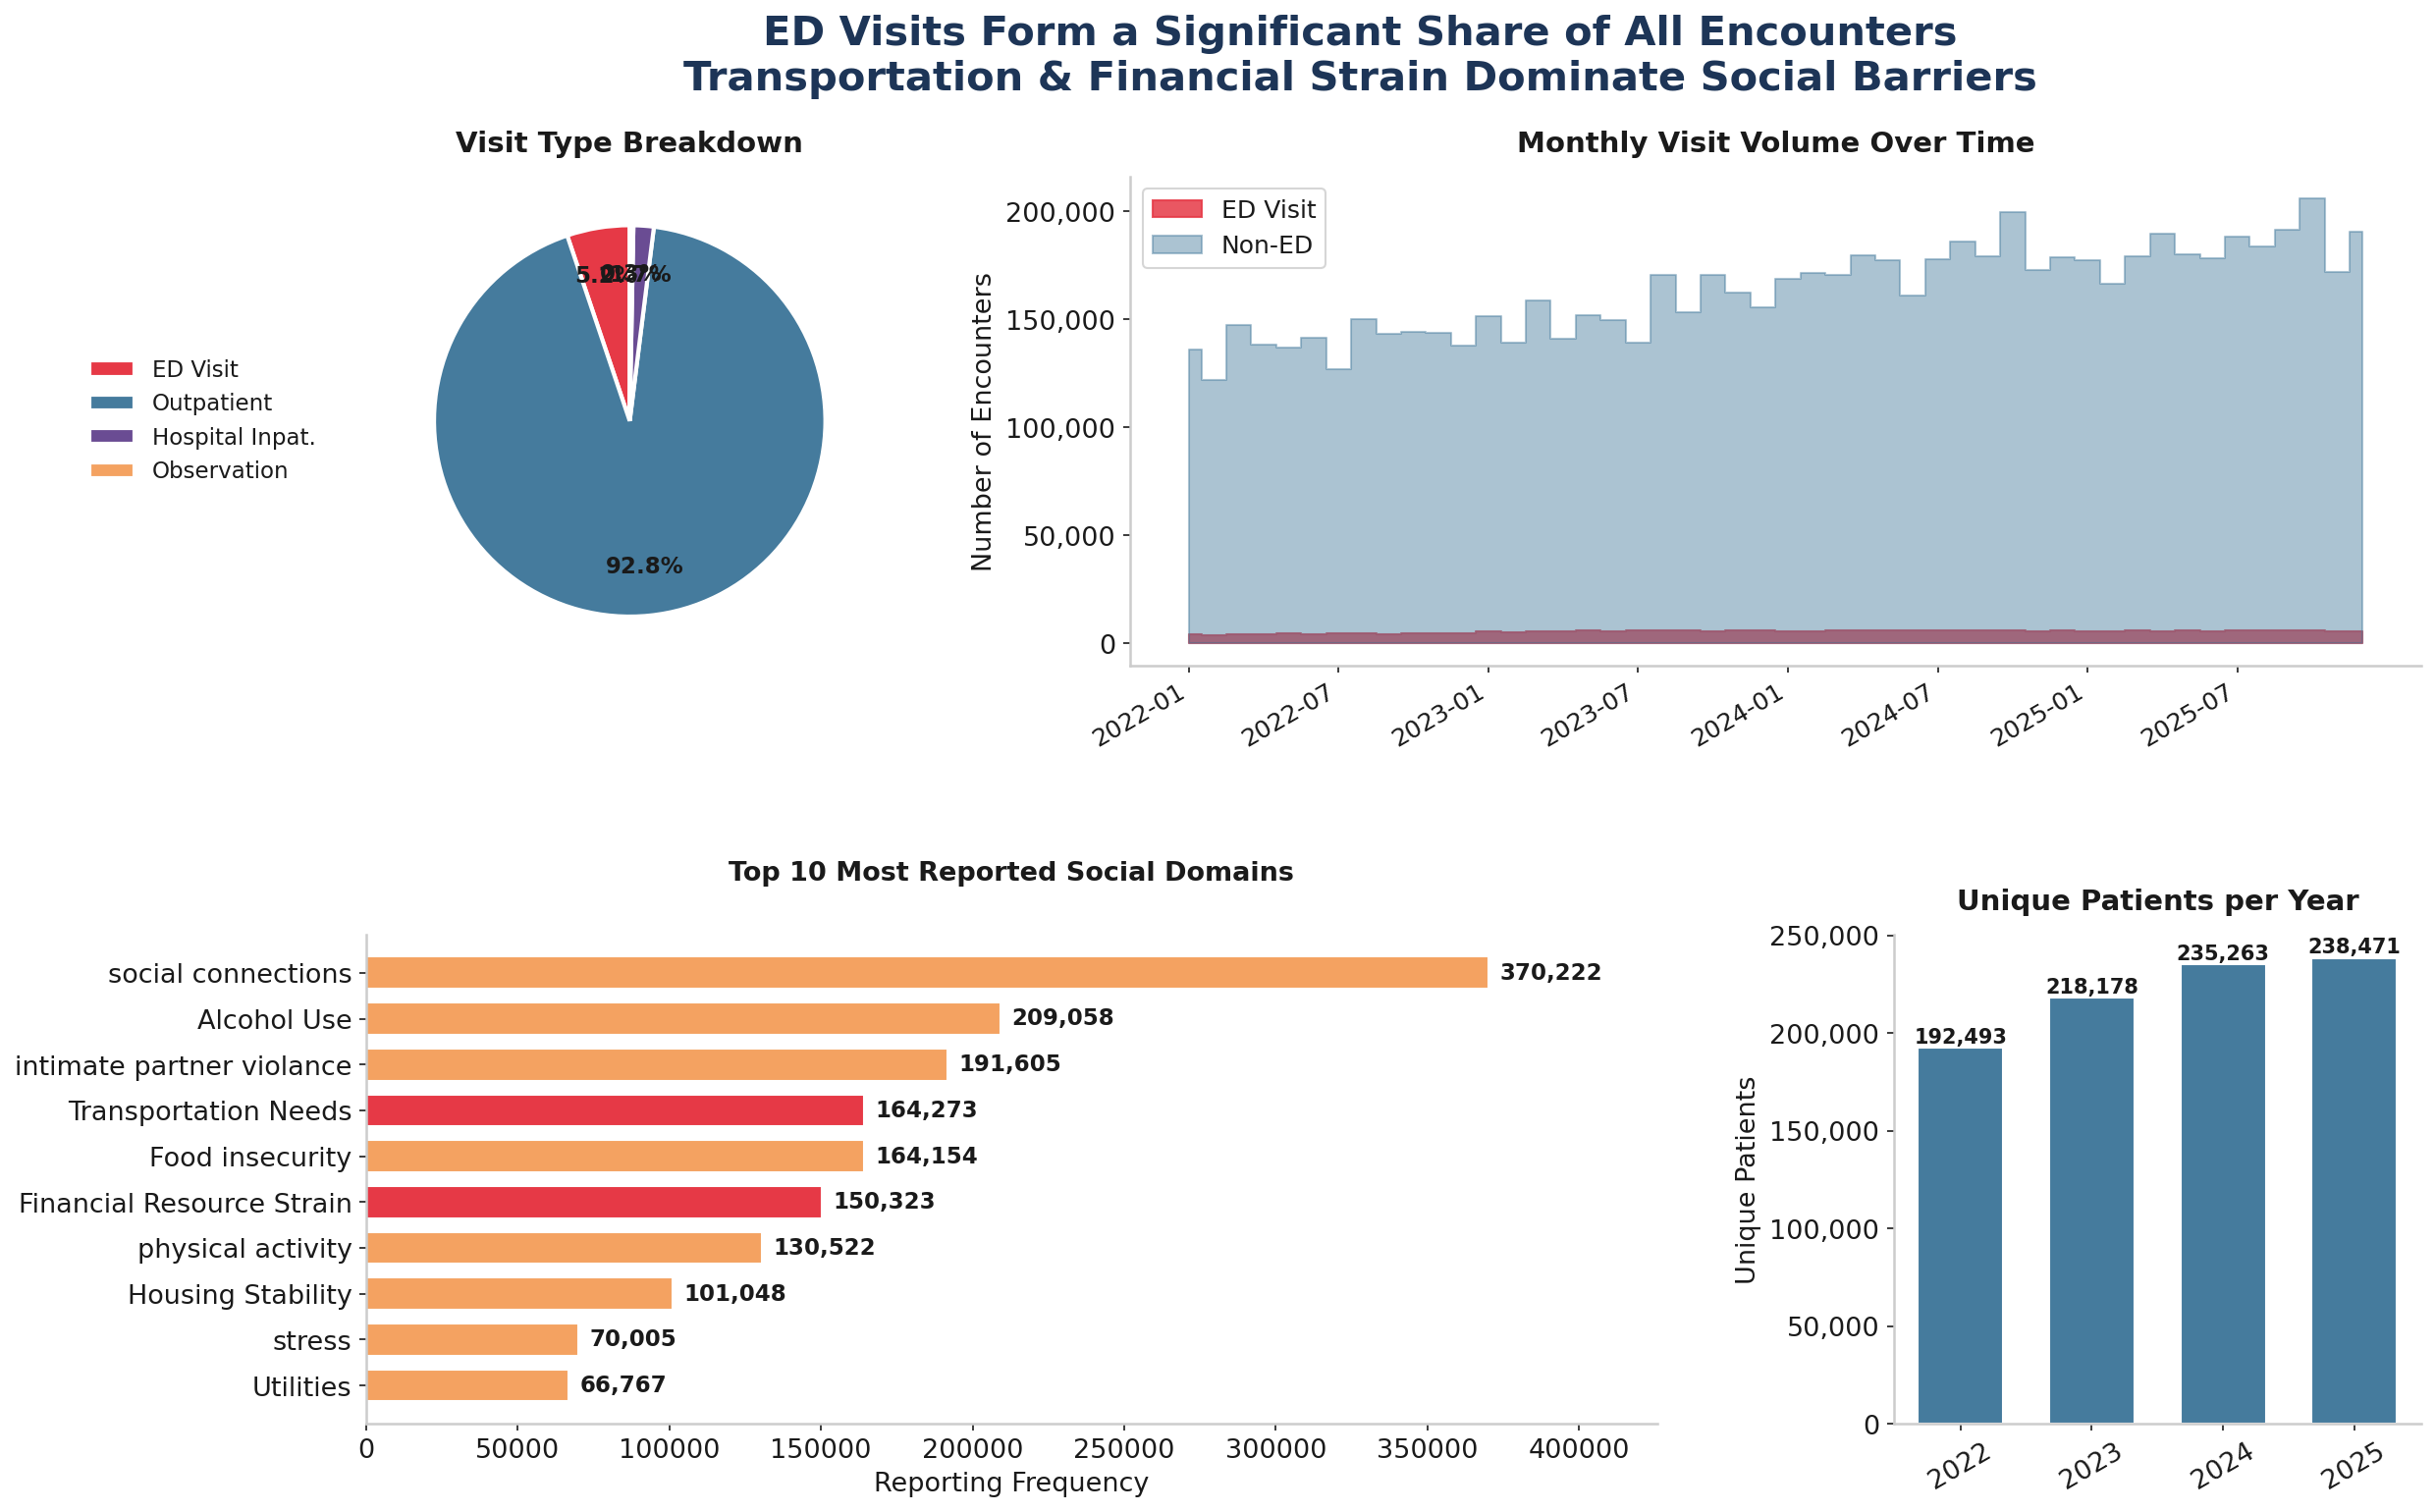

In [4]:
fig = plt.figure(figsize=(18, 11))
fig.patch.set_facecolor("white")

# Title
fig.suptitle(
    "ED Visits Form a Significant Share of All Encounters\n"
    "Transportation & Financial Strain Dominate Social Barriers",
    fontsize=20, fontweight="bold", y=0.98, color="#1d3557"
)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.55, wspace=0.45)

# 1. Visit type composition
ax0 = fig.add_subplot(gs[0, 0])
visit_types = {
    "ED Visit":         enc["IsEdVisit"].sum(),
    "Outpatient":       enc["IsOutpatientFaceToFaceVisit"].sum() if "IsOutpatientFaceToFaceVisit" in enc.columns else 0,
    "Hospital Inpat.":  enc["IsInpatientAdmission"].sum()        if "IsInpatientAdmission"        in enc.columns else 0,
    "Observation":      enc["IsObservation"].sum()               if "IsObservation"               in enc.columns else 0,
}
visit_types = {k: v for k, v in visit_types.items() if v > 0}
wedges, texts, autos = ax0.pie(
    visit_types.values(), 
    labels=None,
    colors=[C_ED, C_OUT, C_PURPLE, C_WARN][:len(visit_types)],
    autopct="%1.1f%%", 
    startangle=90,
    pctdistance=0.75,
    wedgeprops=dict(edgecolor="white", linewidth=2),
    textprops={"fontsize": 12, "fontweight": "bold"}
)
for auto in autos:
    auto.set_fontsize(11)
    auto.set_fontweight("bold")
ax0.legend(
    wedges, 
    visit_types.keys(),
    loc="center right",
    bbox_to_anchor=(-0.1, 0.5),
    fontsize=11,
    frameon=False
)
ax0.set_title("Visit Type Breakdown", fontweight="bold", fontsize=14, pad=12)


# Monthly visit volume
ax1 = fig.add_subplot(gs[0, 1:3])
enc["YearMonth"] = enc["Date"].dt.to_period("M")
monthly = enc.groupby(["YearMonth","IsEdVisit"]).size().unstack(fill_value=0)
monthly.index = monthly.index.astype(str)
if True in monthly.columns: ax1.fill_between(monthly.index, monthly[True], alpha=0.85, color=C_ED,  label="ED Visit", step="mid")
if False in monthly.columns: ax1.fill_between(monthly.index, monthly[False], alpha=0.45, color=C_OUT, label="Non-ED", step="mid")
step = max(1, len(monthly)//8)

ax1.set_xticks(range(0, len(monthly), step))
ax1.set_xticklabels(monthly.index[::step], rotation=30, ha="right", fontsize=12)
ax1.set_ylabel("Number of Encounters", fontsize=13)
ax1.set_title("Monthly Visit Volume Over Time", fontweight="bold", fontsize=14, pad=12)
ax1.legend(fontsize=12, framealpha=0.8)
ax1.yaxis.set_major_formatter(FuncFormatter(lambda x,_: f"{int(x):,}"))
for sp in ["top","right"]: ax1.spines[sp].set_visible(False)


# Most-reported social domains
ax2 = fig.add_subplot(gs[1, 0:2])
domain_counts = soc["Domain"].value_counts().head(10)
cols_domain = [C_ED if ("Transport" in d or "Financial" in d) else C_WARN for d in domain_counts.index]
bars = ax2.barh(domain_counts.index[::-1], domain_counts.values[::-1],
                color=list(reversed(cols_domain)), edgecolor="white", height=0.7)
for b in bars:
    ax2.text(b.get_width() + domain_counts.max()*0.01, b.get_y()+b.get_height()/2,
             f"{b.get_width():,}", va="center", fontsize=11, fontweight="bold")
ax2.set_xlabel("Reporting Frequency", fontsize=13)
ax2.set_title("Top 10 Most Reported Social Domains\n", fontweight="bold", fontsize=13, pad=12)
ax2.set_xlim(0, domain_counts.max() * 1.15)
for sp in ["top","right"]: ax2.spines[sp].set_visible(False)


# Unique patients per year
ax3 = fig.add_subplot(gs[1, 2])
enc["Year"] = enc["Date"].dt.year
yearly_pat  = enc.groupby("Year")["PatientDurableKey"].nunique()
yearly_pat  = yearly_pat[yearly_pat.index > 2000]
bars_y = ax3.bar(yearly_pat.index.astype(str), yearly_pat.values,
                  color=C_OUT, edgecolor="white", width=0.65)
for b in bars_y:
    ax3.text(b.get_x()+b.get_width()/2, b.get_height() + yearly_pat.max()*0.01,
             f"{int(b.get_height()):,}", ha="center", fontsize=10, fontweight="bold")
ax3.set_ylabel("Unique Patients", fontsize=13)
ax3.set_title("Unique Patients per Year", fontweight="bold", fontsize=14, pad=12)
ax3.tick_params(axis="x", rotation=30)
ax3.yaxis.set_major_formatter(FuncFormatter(lambda x,_: f"{int(x):,}"))
for sp in ["top","right"]: ax3.spines[sp].set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.96])
savefig(fig, "P0_system_portrait")


### What do we see here?

SVH data spans hundreds of thousands of encounters from thousands of unique patients.
One thing stands out immediately: ED visits are not a minor phenomenon,
they represent a **significant share of all interactions** with the health system.

And when we look at the most frequently reported social domains, two names rise to the top:
**Transportation Needs** and **Financial Resource Strain**.

### Hypothesis
*"We often assume people go to the ER because their condition suddenly worsens. But the data tells a different story, they go to the ER because there is no other option."*

Patients who end up in the ER are those who previously showed signs of socio-economic difficulty: transportation barriers and financial strain.
Thus the ER becomes the last resort for people who cannot access regular clinics.

We will prove this in three steps:
1. **Financial** : Does financial strain increase the probability of an ED visit?
2. **Transportation** : Is the lack of transport a problem on its own, or is it just a sign of being poor?
3. **Geography** : Does living far from the hospital compound both barriers?


### 1.1 The Connection Between Barriers and ER

do patients who report Financial Resource Strain visit the ER more often than those who do not?

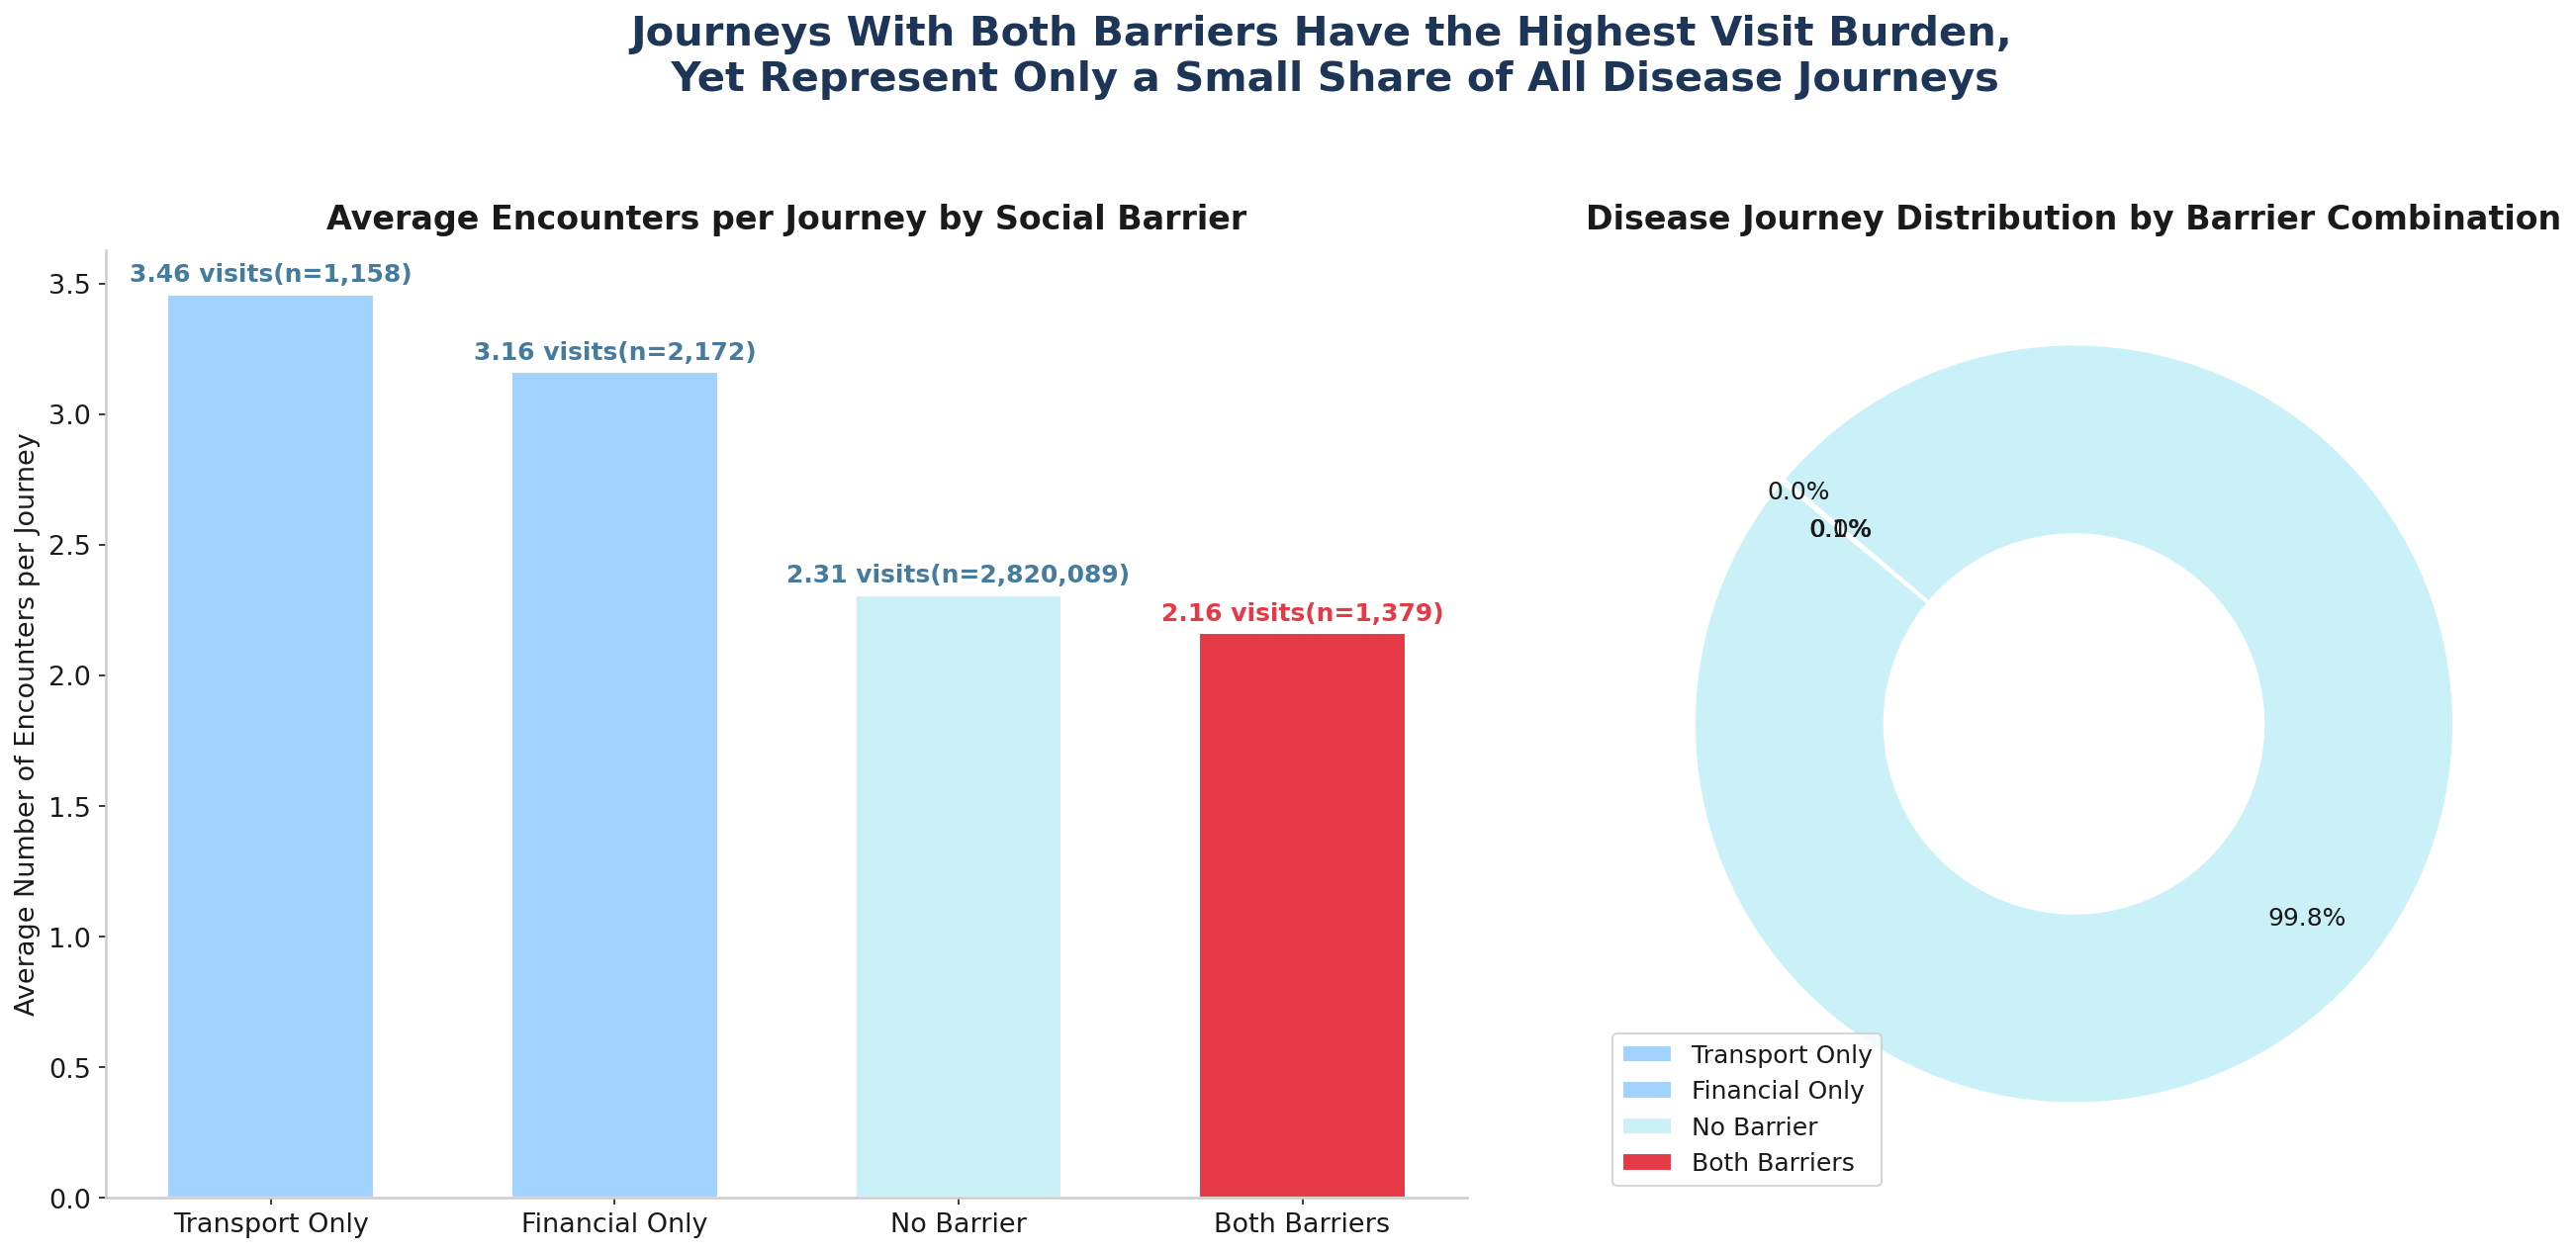

In [5]:
# Unit analisis: journey penyakit (PatientDurableKey + DiagnosisValue)
# VisitCount = jumlah encounter dalam satu journey, bukan total kunjungan pasien
journey_summary = master.groupby(["PatientDurableKey","DiagnosisValue"]).agg(
    VisitCount    = ("EncounterKey","count"),
    Barrier_Group = ("Barrier_Group","first")
).reset_index()

avg_visits_df = (journey_summary.groupby("Barrier_Group")["VisitCount"]
                 .mean()
                 .reset_index()
                 .sort_values("VisitCount", ascending=False))

sorted_order = avg_visits_df["Barrier_Group"].tolist()
avg_values   = avg_visits_df["VisitCount"].tolist()

counts_map = journey_summary["Barrier_Group"].value_counts()
pop_abs    = counts_map.reindex(sorted_order).fillna(0)
pop_dist   = (counts_map / len(journey_summary) * 100).reindex(sorted_order).fillna(0)

def get_color(name):
    if "Both" in str(name): return C_HIGHLIGHT
    elif "Only" in str(name): return C_SOFT_BLUE
    else: return C_LIGHT_BLUE

current_colors = [get_color(n) for n in sorted_order]

fig = plt.figure(figsize=(18, 8))
fig.patch.set_facecolor("white")
gs  = gridspec.GridSpec(1, 2, width_ratios=[1.2, 1])
fig.suptitle(
    "Journeys With Both Barriers Have the Highest Visit Burden, \n Yet Represent Only a Small Share of All Disease Journeys",
    fontsize=20, 
    fontweight="bold", 
    color="#1d3557", 
    y=1.05
)

# Bar Chart
ax1 = fig.add_subplot(gs[0])
bars1 = ax1.bar(sorted_order, avg_values, color=current_colors, width=0.6, edgecolor="white")
ax1.set_title("Average Encounters per Journey by Social Barrier", fontsize=16, fontweight="bold", pad=10)
ax1.set_ylabel("Average Number of Encounters per Journey", fontsize=13)
sns.despine(ax=ax1); ax1.grid(False)

highlight_rgba = mpl.colors.to_rgba(C_HIGHLIGHT)
for b, v, n in zip(bars1, avg_values, pop_abs.values):
    is_h = tuple(b.get_facecolor()) == highlight_rgba
    ax1.text(b.get_x()+b.get_width()/2, v+0.05,
             f"{v:.2f} visits(n={n:,.0f})",
             ha="center", 
             fontsize=12, 
             fontweight="bold",
             color=C_HIGHLIGHT if is_h else "#457B9D")

# Donut Chart
ax2  = fig.add_subplot(gs[1])
expl = [0.15 if "Both" in str(n) else 0 for n in sorted_order]
wedges, texts, autos = ax2.pie(
    pop_dist.values, 
    autopct="%1.1f%%", 
    startangle=140,
    explode=expl, 
    colors=current_colors,
    wedgeprops=dict(width=0.5, edgecolor="white"), 
    pctdistance=0.8,
    textprops={"fontsize": 12}
)
ax2.set_title("Disease Journey Distribution by Barrier Combination",fontsize=16, fontweight="bold", pad=10)
ax2.legend(sorted_order, loc="lower left", fontsize=12)

plt.tight_layout()
savefig(fig, "B1_02_population_visit_barrier")


### 1.2 Combined Effect: Who Is Most Vulnerable?

We now know that these 2 barriers often co-occur. Do their effects multiply making a much higher ED rate than those with just one barrier? 

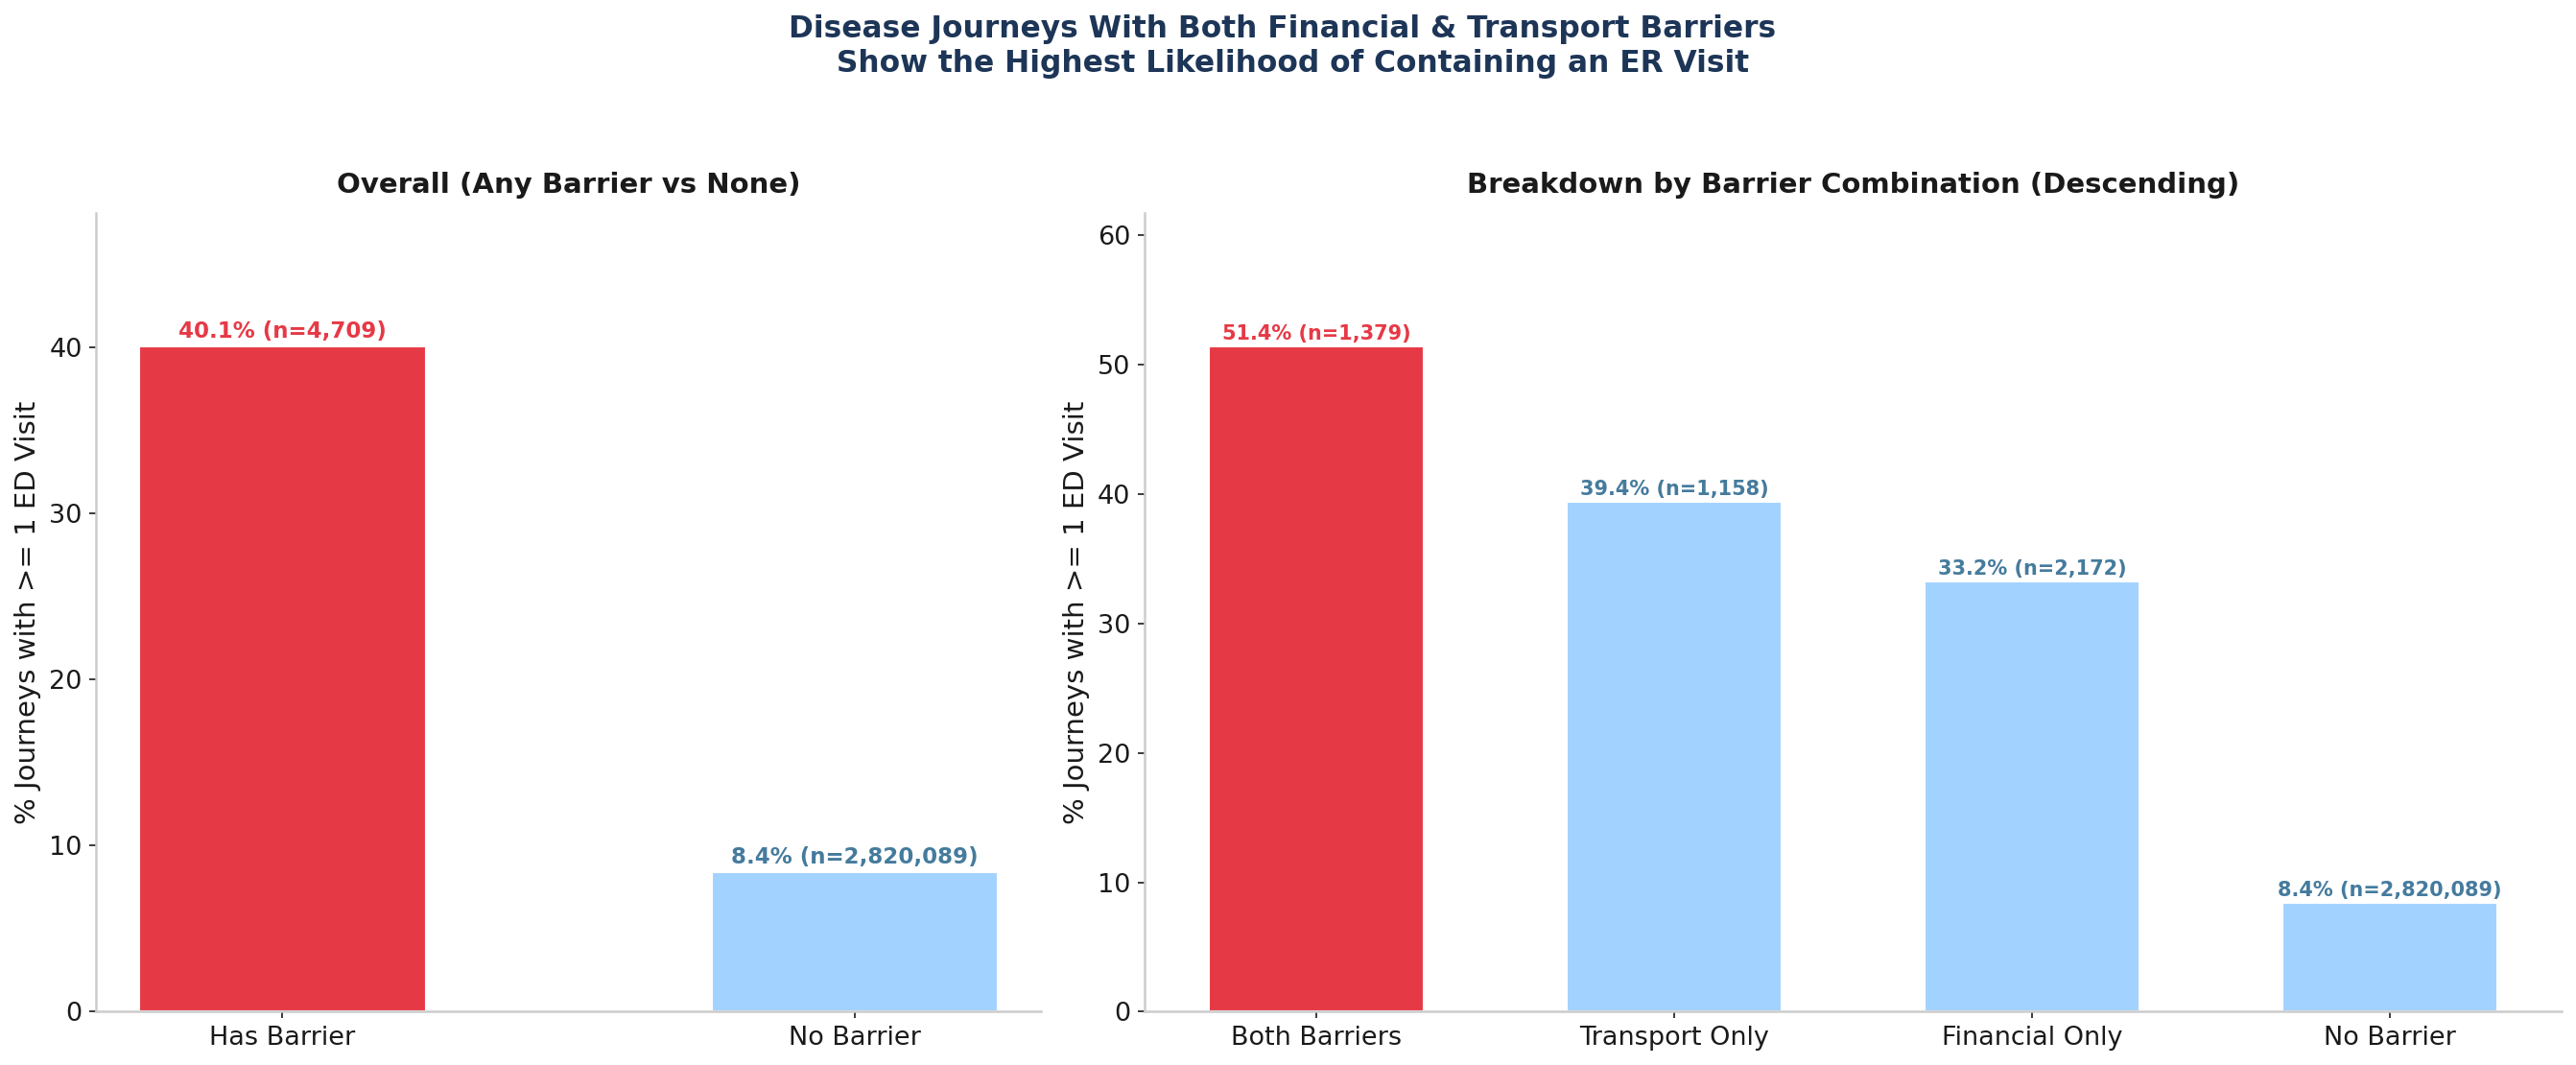

In [6]:
# Apakah journey dengan barrier lebih sering berakhir ke ED?
# Unit: satu journey = (PatientDurableKey, DiagnosisValue)
journey_ed_status = master.groupby(["PatientDurableKey","DiagnosisValue"]).agg(
    IsEdVisit     = ("IsEdVisit","max"),    # journey pernah masuk ED?
    Any_Barrier   = ("Any_Barrier","max"),
    Barrier_Group = ("Barrier_Group","first")
).reset_index()

pat_bar_gen_df = (journey_ed_status.groupby("Any_Barrier")["IsEdVisit"]
                  .mean().mul(100).reset_index())
pat_bar_gen_df["label"] = pat_bar_gen_df["Any_Barrier"].map({
    True : "Has Barrier",
    False : "No Barrier"
})
pat_bar_gen_df = pat_bar_gen_df.sort_values("IsEdVisit", ascending=False)
n_pat_gen = journey_ed_status.groupby("Any_Barrier").size()

pat_bar_det_df = (journey_ed_status.groupby("Barrier_Group")["IsEdVisit"]
                  .mean().mul(100).reset_index()
                  .sort_values("IsEdVisit", ascending=False))
n_pat_det = journey_ed_status.groupby("Barrier_Group").size()


fig, axes = plt.subplots(1, 2, figsize=(18, 7), gridspec_kw={"width_ratios":[1,1.5]})
fig.patch.set_facecolor("white")
fig.suptitle(
    "Disease Journeys With Both Financial & Transport Barriers \n Show the Highest Likelihood of Containing an ER Visit",
    fontsize=15, fontweight="bold", color="#1d3557", y=1.05
)

# Any barriers vs none
ax1 = axes[0]
colors_gen = [C_HIGHLIGHT if "Has Barrier" == lbl else C_SOFT_BLUE
              for lbl in pat_bar_gen_df["label"]]
bars1 = ax1.bar(pat_bar_gen_df["label"], 
                pat_bar_gen_df["IsEdVisit"],
                color=colors_gen,
                width=0.5, 
                edgecolor="white")
ax1.set_title("Overall (Any Barrier vs None)", fontsize=14, fontweight="bold", pad=10)
ax1.set_ylabel("% Journeys with >= 1 ED Visit", fontsize=14)
ax1.set_ylim(0, max(pat_bar_gen_df["IsEdVisit"]) * 1.2)
for b, label, v in zip(bars1, pat_bar_gen_df["label"], pat_bar_gen_df["IsEdVisit"]):
    orig_key = True if "Has Barrier" == label else False
    n = n_pat_gen.get(orig_key, 0)
    ax1.text(b.get_x()+b.get_width()/2, v+0.5,
             f"{v:.1f}% (n={n:,})", 
             ha="center", fontsize=11, fontweight="bold",
             color=C_HIGHLIGHT if "Has Barrier"==label else "#457B9D")
for sp in ["top","right"]: ax1.spines[sp].set_visible(False)

# Barrier Combination
ax2 = axes[1]
colors_det = [C_HIGHLIGHT if i==0 else C_SOFT_BLUE for i, _ in enumerate(pat_bar_det_df["Barrier_Group"])]
bars2 = ax2.bar(pat_bar_det_df["Barrier_Group"], 
                pat_bar_det_df["IsEdVisit"],
                color=colors_det, 
                width=0.6, 
                edgecolor="white")
ax2.set_title("Breakdown by Barrier Combination (Descending)", fontsize=14, fontweight="bold", pad=10)
ax2.set_ylabel("% Journeys with >= 1 ED Visit", fontsize=14)
ax2.set_ylim(0, max(pat_bar_det_df["IsEdVisit"]) * 1.2)
for b, grp, v in zip(bars2, pat_bar_det_df["Barrier_Group"], pat_bar_det_df["IsEdVisit"]):
    n = n_pat_det.get(grp, 0)
    ax2.text(b.get_x()+b.get_width()/2, v+0.5,
             f"{v:.1f}% (n={n:,})", ha="center", fontsize=10, fontweight="bold",
             color=C_HIGHLIGHT if grp == pat_bar_det_df["Barrier_Group"].iloc[0] else "#457B9D")
for sp in ["top","right"]: ax2.spines[sp].set_visible(False)

plt.tight_layout()
savefig(fig, "B1_03_ED_rate_barrier_detail")


### 1.3 Mayority of Diagnosis Experienced by Patients With Barriers 

We need to question whatmost diagnosis effects patients with barriers

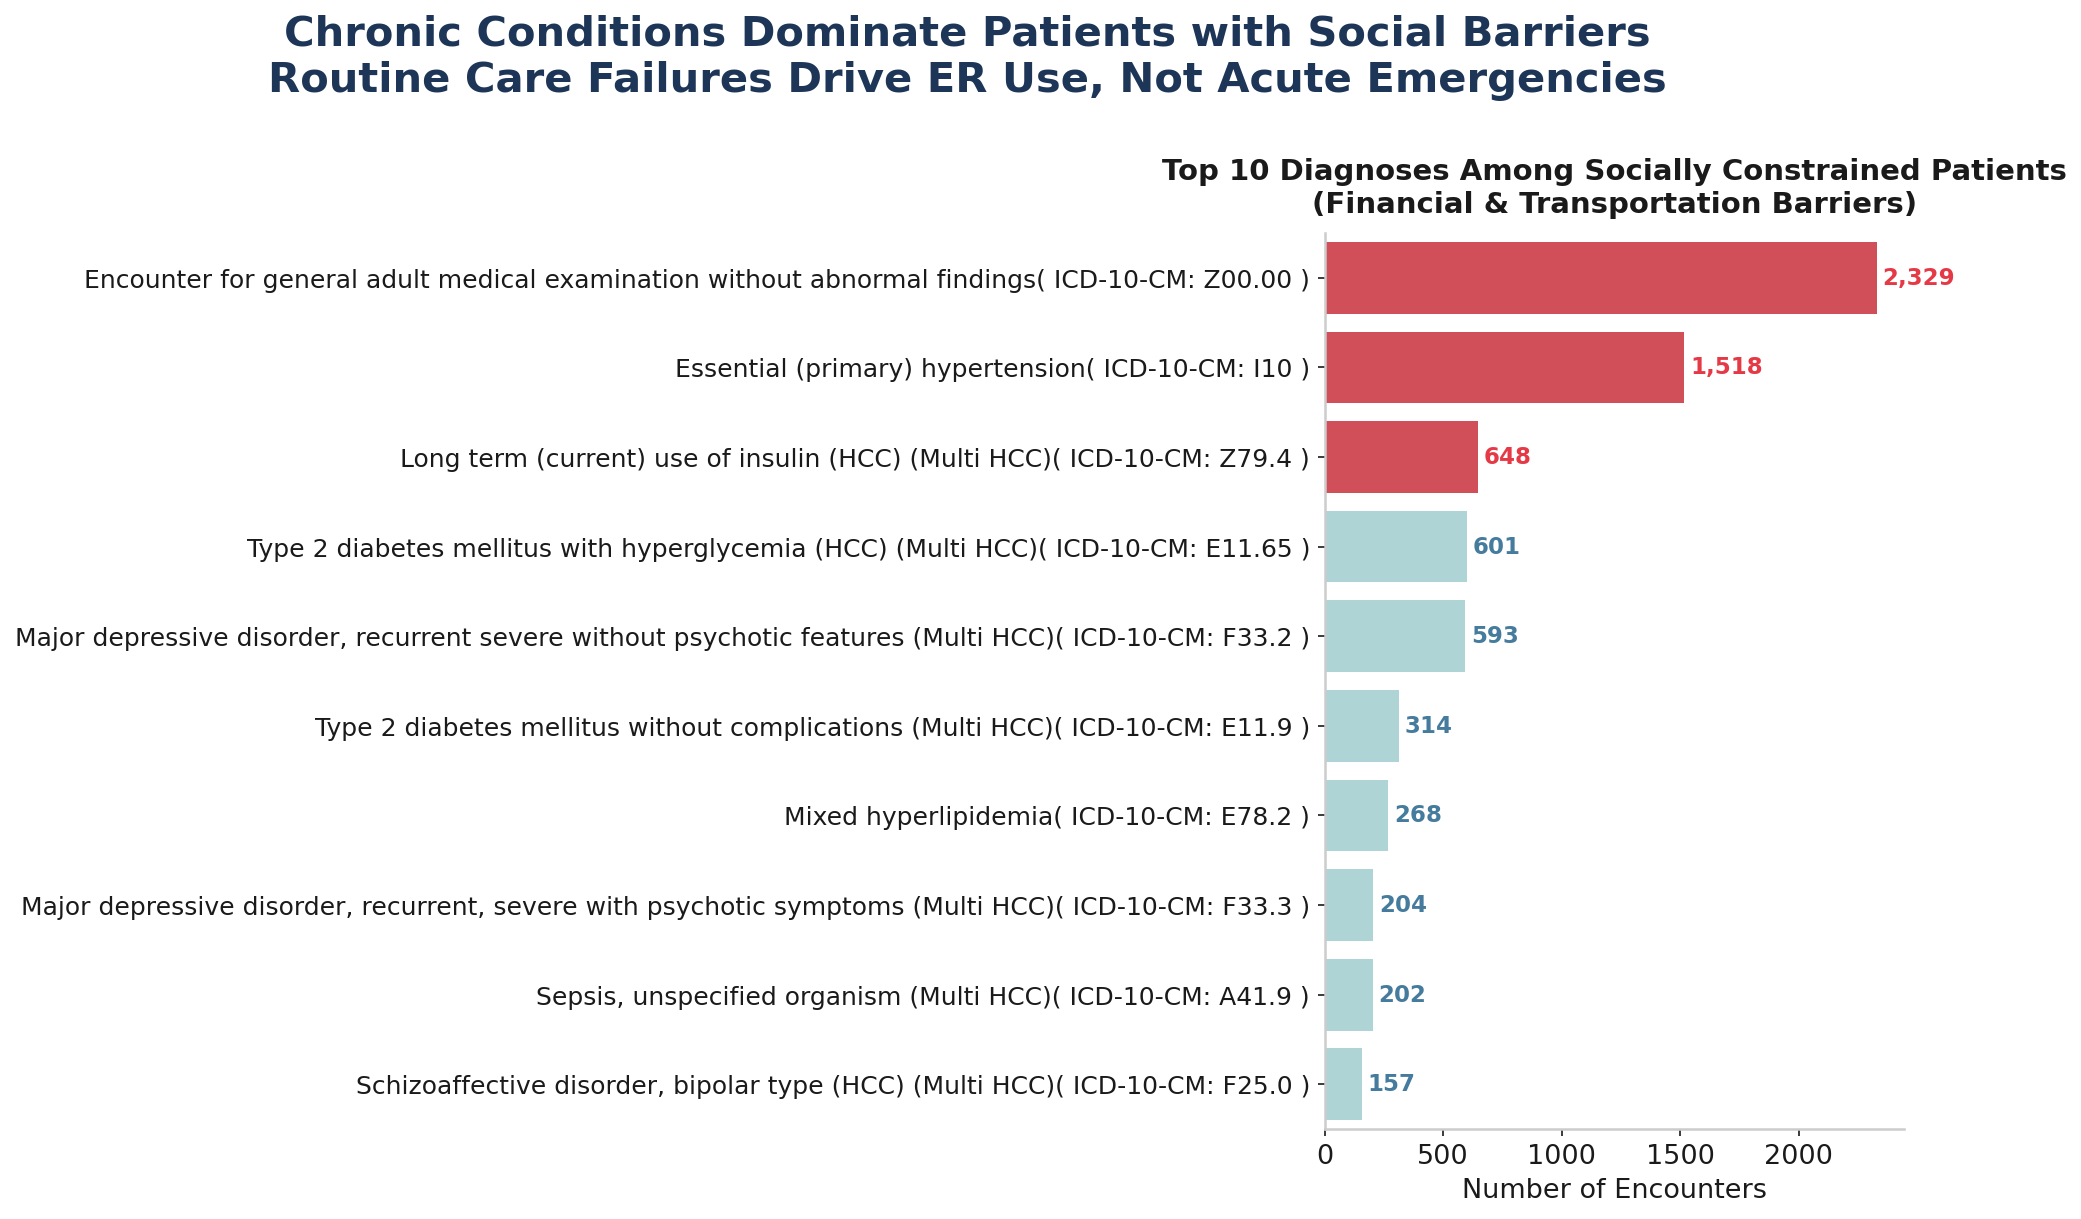

In [7]:
master_full = master.merge(
    diag[["DiagnosisKey","DiagnosisName"]],
    left_on="PrimaryDiagnosisKey", 
    right_on="DiagnosisKey", 
    how="left"
)

barrier_only    = master_full[master_full["Barrier_Group"] != "No Barrier"].copy()
top_10_diseases = barrier_only["DiagnosisName"].value_counts().nlargest(10).index
plot_data       = barrier_only[barrier_only["DiagnosisName"].isin(top_10_diseases)]

fig, ax = plt.subplots(figsize=(13, 8))
fig.patch.set_facecolor("white")

custom_palette = ["#E63946" if i < 3 else "#A8DADC" for i in range(len(top_10_diseases))]

ax = sns.countplot(data=plot_data, 
                   y="DiagnosisName",
                   order=top_10_diseases,
                   palette=custom_palette,
                   edgecolor=None, ax=ax)

fig.suptitle(
    "Chronic Conditions Dominate Patients with Social Barriers\n"
    "Routine Care Failures Drive ER Use, Not Acute Emergencies",
    fontsize=20, 
    fontweight="bold", 
    y=1.01, 
    color="#1d3557"
)
ax.set_title("Top 10 Diagnoses Among Socially Constrained Patients\n(Financial & Transportation Barriers)",
             fontsize=14, 
             fontweight="bold", 
             pad=10)
ax.set_xlabel("Number of Encounters", fontsize=13)
ax.set_ylabel("", fontsize=1)
ax.grid(False); sns.despine()
ax.tick_params(axis="y", labelsize=12)

for i, p in enumerate(ax.patches):
    width = p.get_width()
    if width > 0:
        text_color = "#E63946" if i < 3 else "#457B9D"
        ax.text(width + (ax.get_xlim()[1]*0.01), p.get_y()+p.get_height()/2,
                f"{int(width):,}", 
                va="center", 
                fontsize=11, 
                fontweight="bold",
                color=text_color)

plt.tight_layout()
savefig(fig, "B1_04_top_diagnoses_barrier_patients")


### 1.4 Spatial Investigation: Where Do ED Patients Live?

Do patients who live far from the hospital and have transport barriers contribute a higher ED rate?


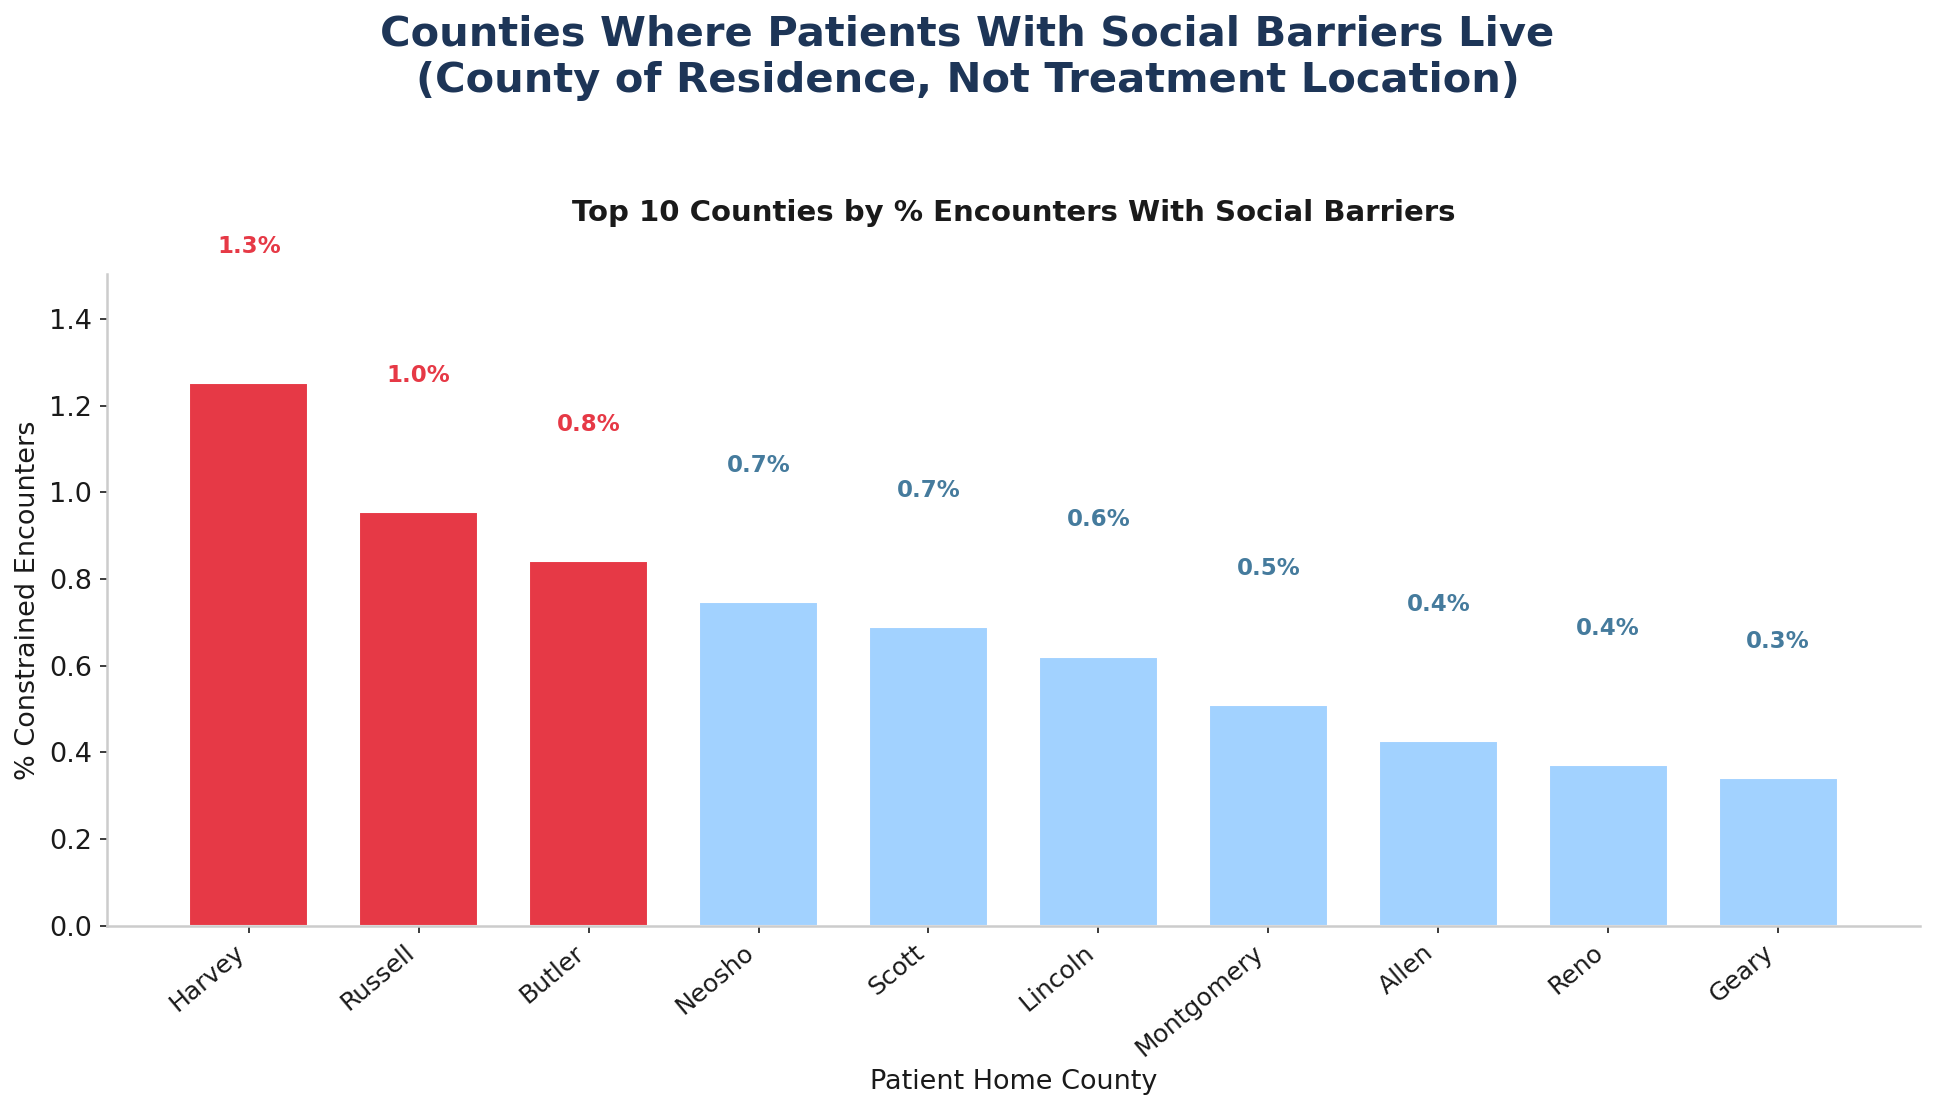

In [9]:
# County assignment FROM PATIENT'S HOME (CensusBlockGroupFipsCode), not department
# FIPS structure: SS CCC TTTTTT B → first 5 digits = state + county
# Kansas state code = 20

# Kansas county FIPS lookup (5-digit county FIPS → name)
KS_COUNTY_NAMES = {
    "20001": "Allen",       "20003": "Anderson",    "20005": "Atchison",
    "20007": "Barber",      "20009": "Barton",      "20011": "Bourbon",
    "20013": "Brown",       "20015": "Butler",      "20017": "Chase",
    "20019": "Chautauqua",  "20021": "Cherokee",    "20023": "Cheyenne",
    "20025": "Clark",       "20027": "Clay",        "20029": "Cloud",
    "20031": "Coffey",      "20033": "Comanche",    "20035": "Cowley",
    "20037": "Crawford",    "20039": "Decatur",     "20041": "Dickinson",
    "20043": "Doniphan",    "20045": "Douglas",     "20047": "Edwards",
    "20049": "Elk",         "20051": "Ellis",       "20053": "Ellsworth",
    "20055": "Finney",      "20057": "Ford",        "20059": "Franklin",
    "20061": "Geary",       "20063": "Gove",        "20065": "Graham",
    "20067": "Grant",       "20069": "Gray",        "20071": "Greeley",
    "20073": "Greenwood",   "20075": "Hamilton",    "20077": "Harper",
    "20079": "Harvey",      "20081": "Haskell",     "20083": "Hodgeman",
    "20085": "Jackson",     "20087": "Jefferson",   "20089": "Jewell",
    "20091": "Johnson",     "20093": "Kearny",      "20095": "Kingman",
    "20097": "Kiowa",       "20099": "Labette",     "20101": "Lane",
    "20103": "Leavenworth", "20105": "Lincoln",     "20107": "Linn",
    "20109": "Logan",       "20111": "Lyon",        "20113": "Marion",
    "20115": "Marshall",    "20117": "McPherson",   "20119": "Meade",
    "20121": "Miami",       "20123": "Mitchell",    "20125": "Montgomery",
    "20127": "Morris",      "20129": "Morton",      "20131": "Nemaha",
    "20133": "Neosho",      "20135": "Ness",        "20137": "Norton",
    "20139": "Osage",       "20141": "Osborne",     "20143": "Ottawa",
    "20145": "Pawnee",      "20147": "Phillips",    "20149": "Pottawatomie",
    "20151": "Pratt",       "20153": "Rawlins",     "20155": "Reno",
    "20157": "Republic",    "20159": "Rice",        "20161": "Riley",
    "20163": "Rooks",       "20165": "Rush",        "20167": "Russell",
    "20169": "Saline",      "20171": "Scott",       "20173": "Sedgwick",
    "20175": "Seward",      "20177": "Shawnee",     "20179": "Sheridan",
    "20181": "Sherman",     "20183": "Smith",       "20185": "Stafford",
    "20187": "Stanton",     "20189": "Stevens",     "20191": "Sumner",
    "20193": "Thomas",      "20195": "Trego",       "20197": "Wabaunsee",
    "20199": "Wallace",     "20201": "Washington",  "20203": "Wichita",
    "20205": "Wilson",      "20207": "Woodson",     "20209": "Wyandotte",
    "20211": "Sedgwick",
}

# Extract county code from each patient's FIPS
pat_with_fips = pat.copy()
# Convert FIPS to numeric first (invalid values like "*Unspecified" → NaN)
pat_with_fips["fips_numeric"] = pd.to_numeric(
    pat_with_fips["CensusBlockGroupFipsCode"], errors="coerce"
)
pat_with_fips = pat_with_fips.dropna(subset=["fips_numeric"])
pat_with_fips["fips_str"] = pat_with_fips["fips_numeric"].astype(np.int64).astype(str)
pat_with_fips["county_code"] = pat_with_fips["fips_str"].str[:5]
pat_with_fips["County"] = pat_with_fips["county_code"].map(KS_COUNTY_NAMES)

# Now assign county to each encounter via patient
df_master_geo = master.merge(
    pat_with_fips[["DurableKey","County"]].rename(columns={"DurableKey":"PatientDurableKey"}),
    on="PatientDurableKey", how="left", suffixes=("","_home")
)
# Use home county; if missing, leave as NaN (don't fall back to dept county)
if "County_home" in df_master_geo.columns:
    df_master_geo["County"] = df_master_geo["County_home"].fillna(df_master_geo.get("County"))

# Now compute % barrier per county (only counties with enough samples)
county_grouped = df_master_geo.dropna(subset=["County"]).groupby("County").agg(
    total_journeys=("Any_Barrier","count"),
    barrier_count=("Any_Barrier","sum")
).reset_index()
county_grouped = county_grouped[county_grouped["total_journeys"] >= 100]
county_grouped["barrier_pct"] = county_grouped["barrier_count"] / county_grouped["total_journeys"] * 100

top_10 = county_grouped.nlargest(10, "barrier_pct").set_index("County")["barrier_pct"]
colors  = ["#e63946" if i < 3 else "#a2d2ff" for i in range(len(top_10))]

fig, ax = plt.subplots(figsize=(13, 7))
fig.patch.set_facecolor("white")
fig.suptitle(
    "Counties Where Patients With Social Barriers Live\n"
    "(County of Residence, Not Treatment Location)",
    fontsize=20, fontweight="bold", color="#1d3557", y=1.05
)
bars_c = ax.bar(top_10.index, top_10.values, color=colors, width=0.7, edgecolor="white")
for i, v in enumerate(top_10.values):
    ax.text(i, v + 0.3, f"{v:.1f}%", ha="center", fontweight="bold", fontsize=11,
            color="#e63946" if i < 3 else "#457B9D")
ax.set_title("Top 10 Counties by % Encounters With Social Barriers\n",
             fontsize=14, fontweight="bold", pad=10)
ax.set_ylabel("% Constrained Encounters", fontsize=13)
ax.set_xlabel("Patient Home County", fontsize=13)
ax.set_ylim(0, top_10.max() * 1.2)
plt.xticks(rotation=40, ha="right", fontsize=12)
for sp in ["top","right"]: ax.spines[sp].set_visible(False)

plt.tight_layout()
savefig(fig, "B1_05_top_county_highlighted")

### 2.1 Patients who decline MyChart enrollment are often those with the highest clinical needs.

In [10]:
display(pat_mc["MyChartStatus"].value_counts().to_frame("Count"))

,Count
MyChartStatus,
*Unspecified,392762
Activated,274082
Pending Activation,177728
Inactivated,65377
Non Standard MyChart Status,35411
Patient Declined,2161
"Activation Code Generated, but Disabled",164


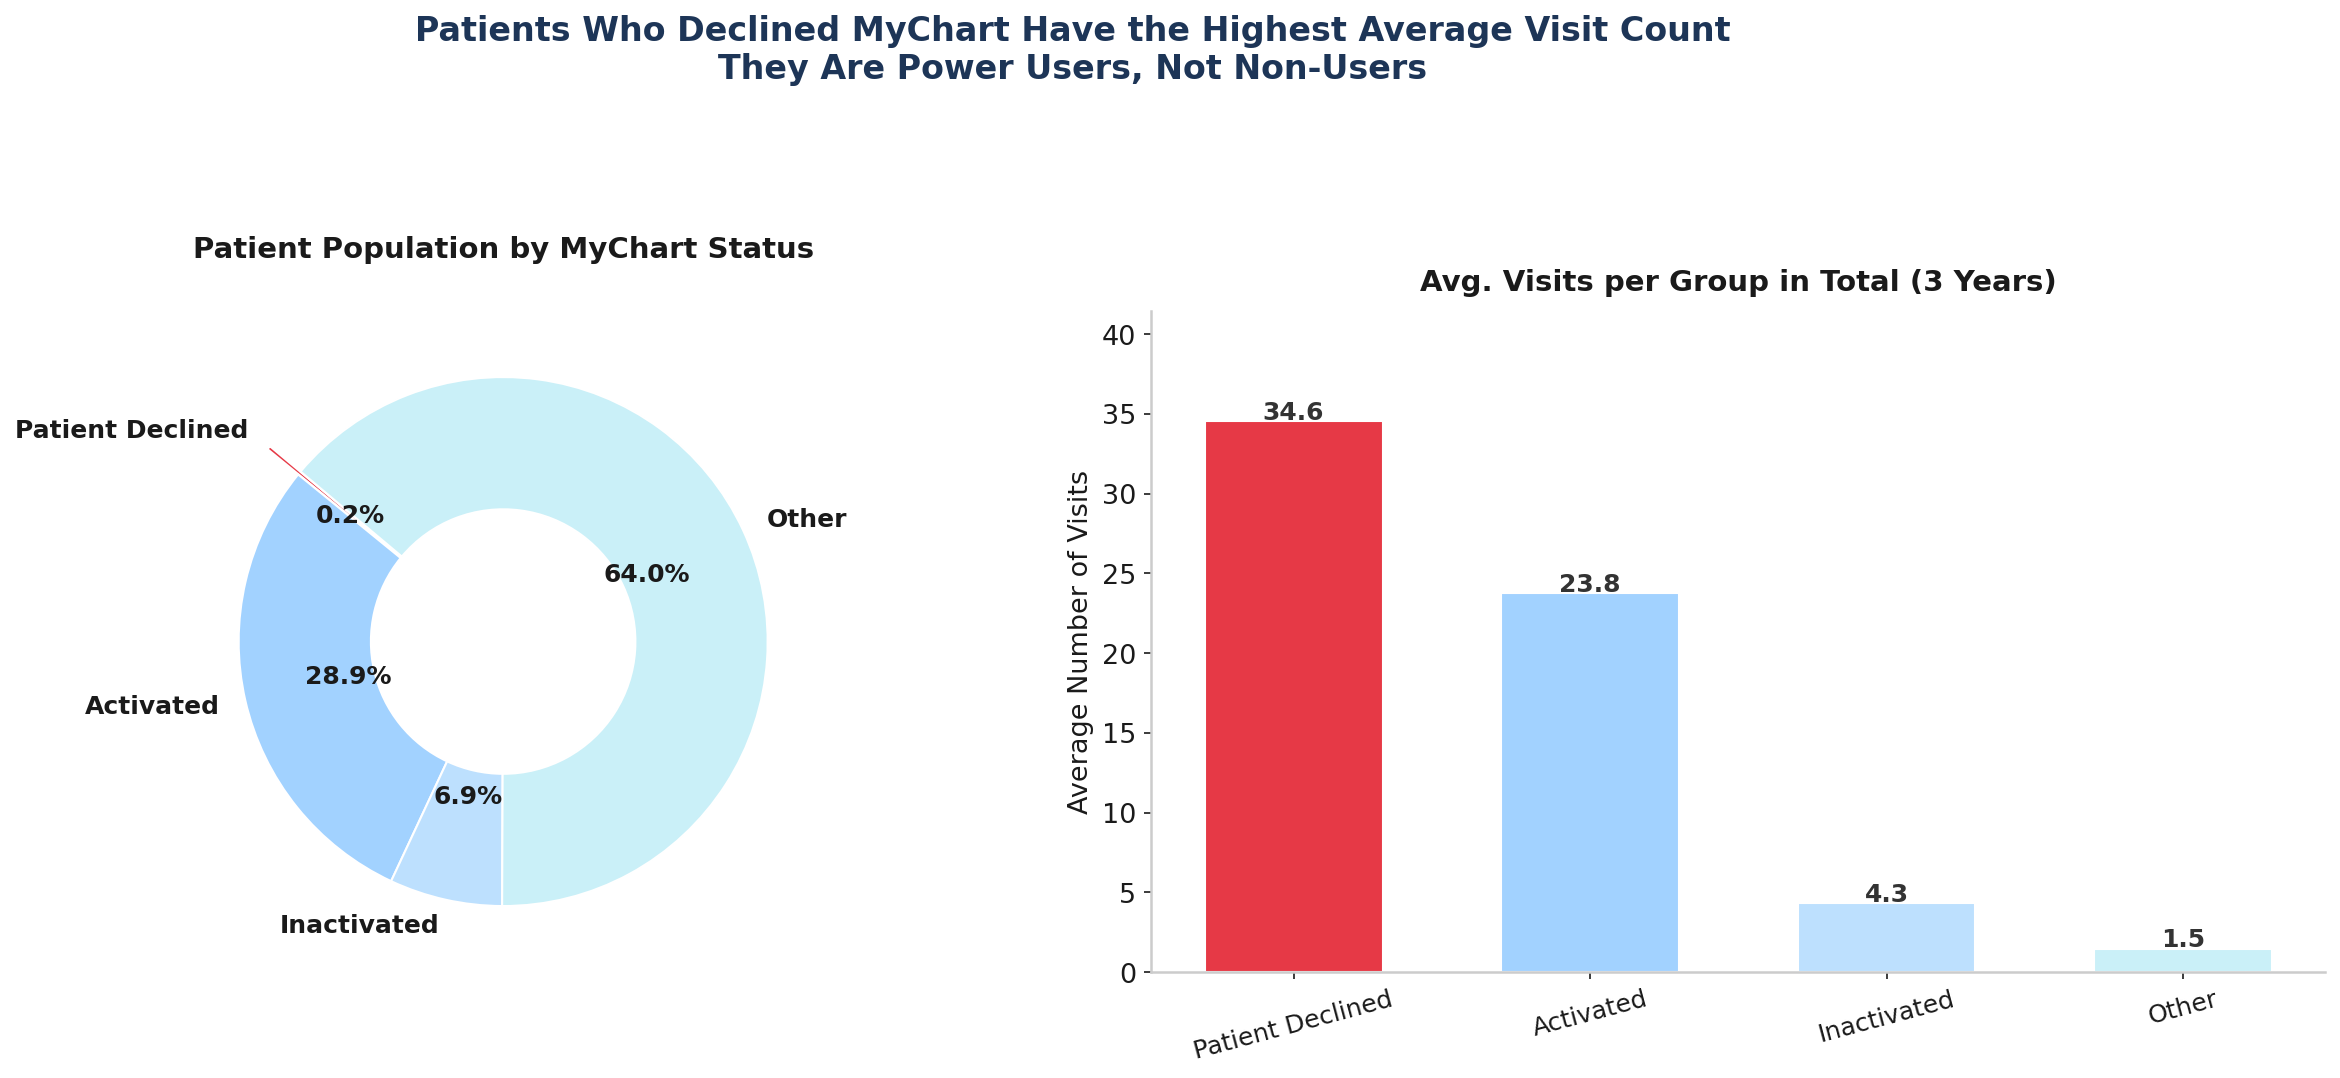

In [11]:
def map_mychart_detailed(status):
    s = str(status).strip()
    if s == "Activated": return "Activated"
    elif s == "Patient Declined": return "Patient Declined"
    elif s in ("Inactivated","Deactivated"): return "Inactivated"
    else: return "Other"

pat_mc["MyChartGroup"] = pat_mc["MyChartStatus"].apply(map_mychart_detailed)

mc_summary = (pat_mc.groupby("MyChartGroup")["VisitCount"]
              .agg(N_Patients="count", Avg_Visits="mean")
              .reset_index()
              .sort_values("Avg_Visits", ascending=False))
sorted_groups = mc_summary["MyChartGroup"].tolist()

COLORS_MAP = {
    "Activated": "#a2d2ff",
    "Patient Declined":"#e63946",
    "Inactivated": "#bde0fe",
    "Other": "#caf0f8"
}

fig, axes = plt.subplots(1, 2, figsize=(17, 7))
fig.patch.set_facecolor("white")
fig.suptitle(
    "Patients Who Declined MyChart Have the Highest Average Visit Count\n"
    "They Are Power Users, Not Non-Users",
    fontsize=16, 
    fontweight="bold", 
    color="#1d3557", 
    y=1.05
)

# Donut Chart
ax1 = axes[0]
mc_dist = pat_mc["MyChartGroup"].value_counts().reindex(sorted_groups).fillna(0)
explode = [0.15 if g=="Patient Declined" else 0 for g in sorted_groups]
ax1.pie(mc_dist.values, 
        labels=mc_dist.index,
        autopct="%1.1f%%",
        startangle=140, 
        explode=explode,
        colors=[COLORS_MAP.get(c,"#888") for c in mc_dist.index],
        wedgeprops=dict(width=0.5, edgecolor="white"),
        textprops={"fontweight":"bold", "fontsize": 12})
ax1.set_title("Patient Population by MyChart Status\n", fontsize=14, fontweight="bold", pad=10)

# Bar Chart
ax2 = axes[1]
bars = ax2.bar(mc_summary["MyChartGroup"], mc_summary["Avg_Visits"],
               color=[COLORS_MAP.get(c,"#888") for c in mc_summary["MyChartGroup"]],
               width=0.6, edgecolor="white")
for b in bars:
    h = b.get_height()
    ax2.text(b.get_x()+b.get_width()/2, h+0.12, f"{h:.1f}",
             ha="center", 
             fontsize=12, 
             fontweight="bold", 
             color="#333")
ax2.set_ylabel("Average Number of Visits", fontsize=13)
ax2.set_title("Avg. Visits per Group in Total (3 Years)", fontsize=14, fontweight="bold", pad=10)
ax2.tick_params(axis="x", rotation=15, labelsize=12)
ax2.set_ylim(0, mc_summary["Avg_Visits"].max() * 1.2)
for sp in ["top","right"]: ax2.spines[sp].set_visible(False)

plt.tight_layout(rect=[0,0.03,1,0.95])
savefig(fig, "B2_01_mychart_visit_analysis")

### 2.2 Age Profile of Patients Who Decline

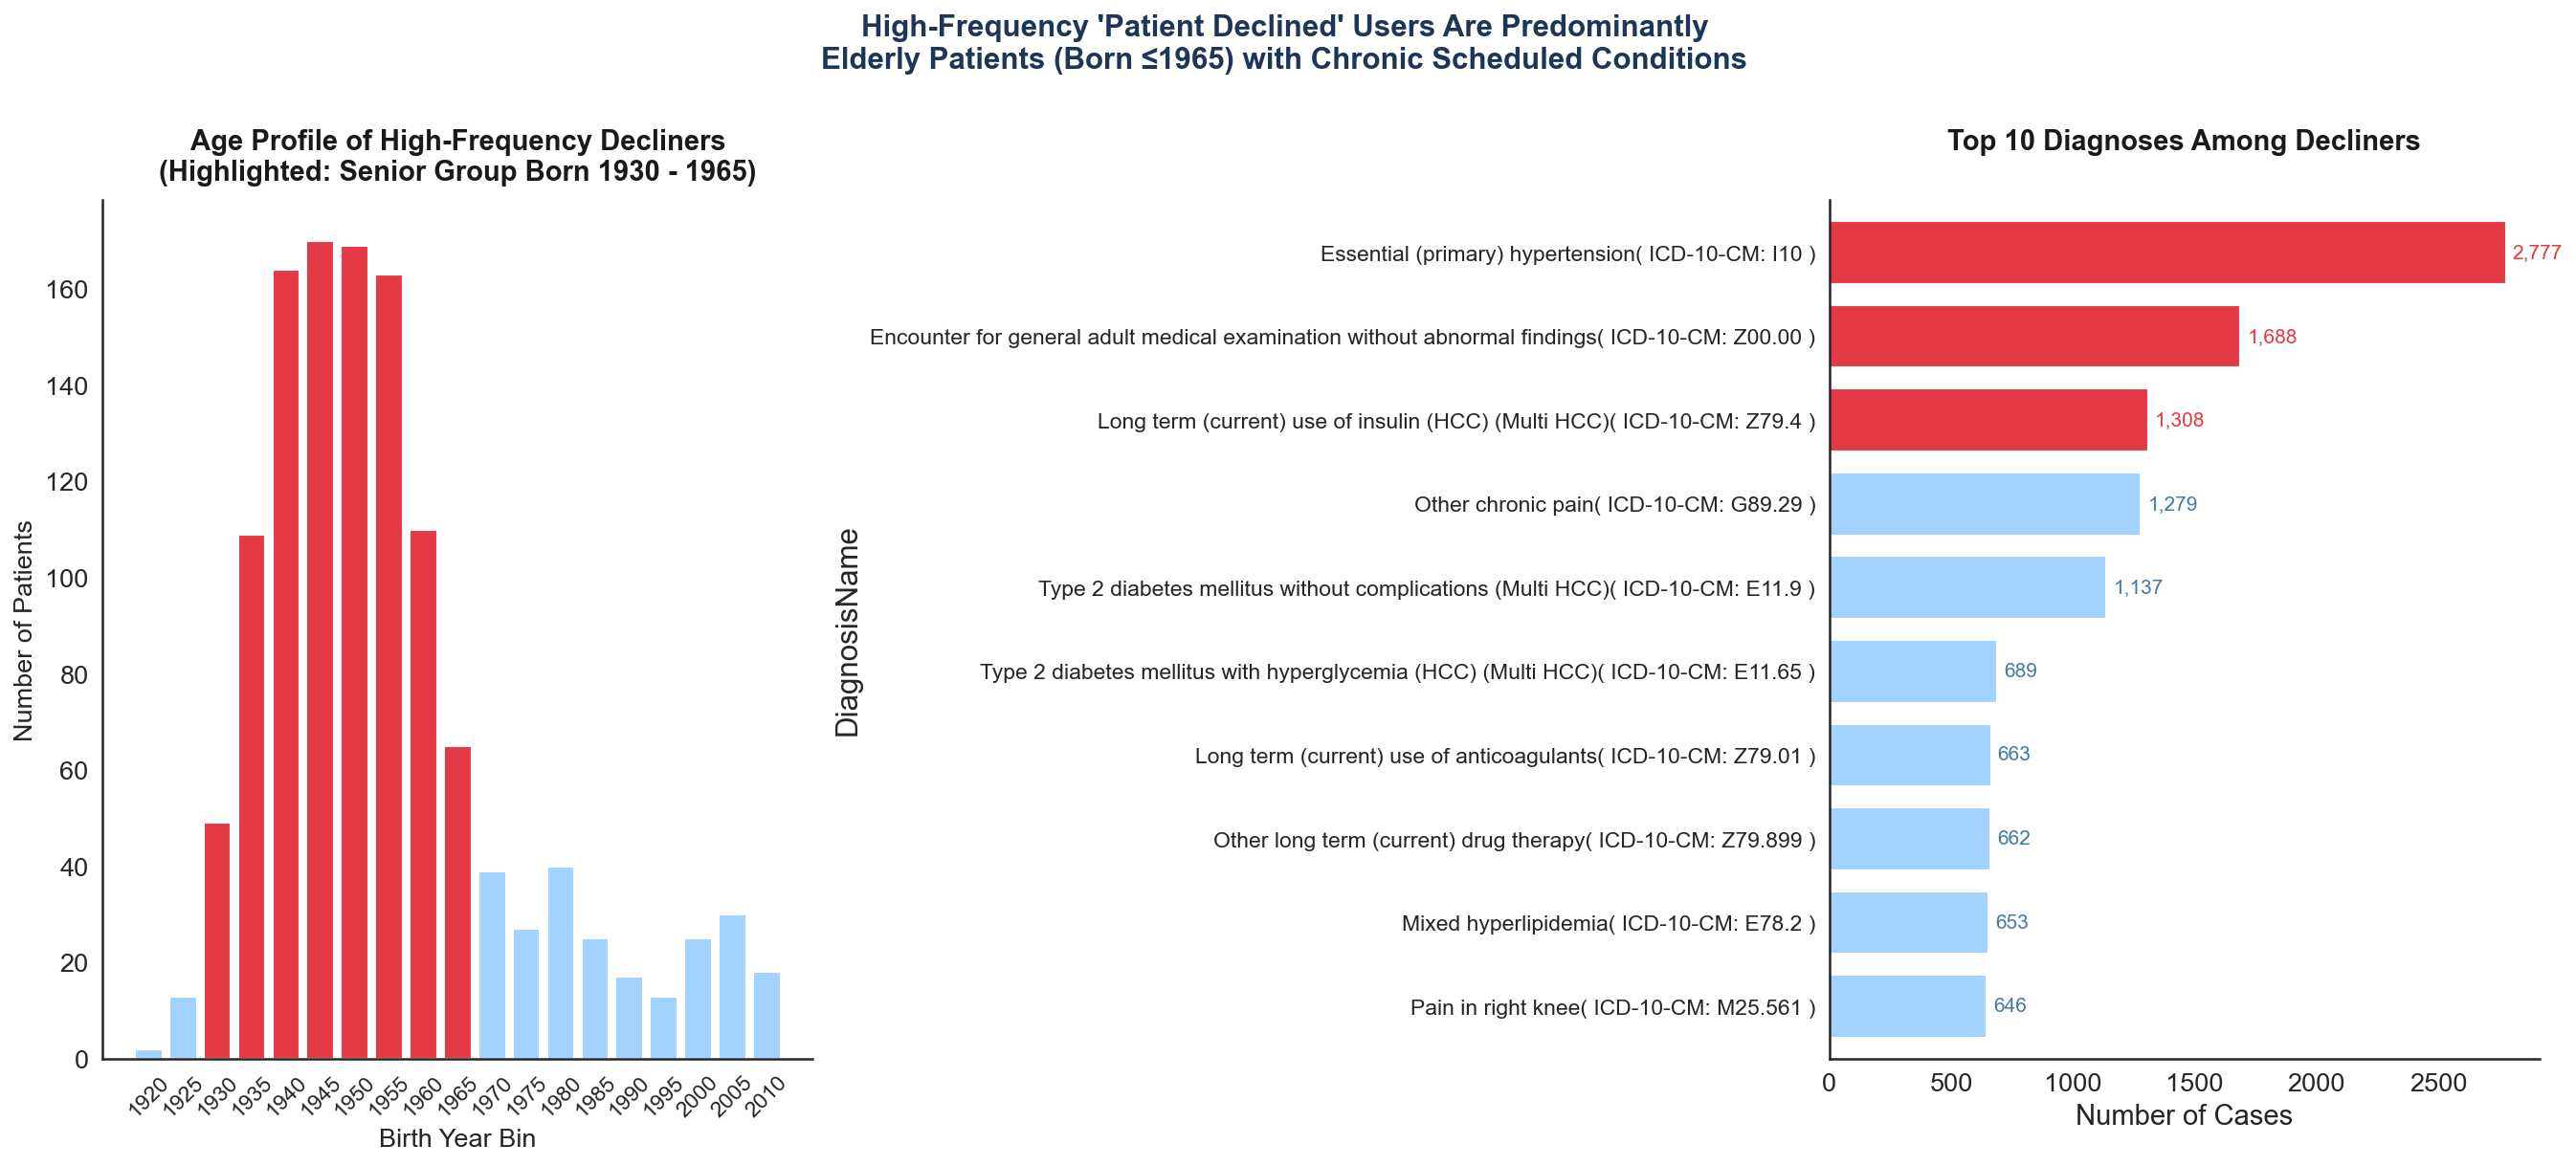

In [12]:
C_SOFT_BLUE = "#a2d2ff"
C_HIGHLIGHT = "#e63946"
sns.set_style("white")

visit_counts_kp2 = enc.groupby("PatientDurableKey").size().reset_index(name="Freq")
df_kp2 = pat.merge(visit_counts_kp2, left_on="DurableKey", right_on="PatientDurableKey")

median_f = df_kp2["Freq"].median()
high_freq_Declined = df_kp2[
    (df_kp2["MyChartStatus"].astype(str).str.contains("decline", case=False, na=False)) &
    (df_kp2["Freq"] > median_f)
].dropna().copy()

if not high_freq_Declined.empty:
    high_freq_Declined["PatientBirthYearBin"] = (
        high_freq_Declined["PatientBirthYearBin"]
        .astype(str).str.replace(".0","",regex=False)
    )

    fig, axes = plt.subplots(1, 2, figsize=(18, 8))
    fig.patch.set_facecolor("white")
    fig.suptitle(
        "High-Frequency 'Patient Declined' Users Are Predominantly\n"
        "Elderly Patients (Born ≤1965) with Chronic Scheduled Conditions",
        fontsize=15, fontweight="bold", y=1.01, color="#1d3557"
    )

    # Age Profile
    ax_a = axes[0]
    counts = high_freq_Declined["PatientBirthYearBin"].dropna().value_counts().sort_index()
    target_bins = [str(y) for y in range(1930, 1966, 5)]
    demo_colors = [C_HIGHLIGHT if b in target_bins else C_SOFT_BLUE for b in counts.index]
    ax_a.bar(counts.index, counts.values, color=demo_colors, edgecolor="white")
    ax_a.set_title("Age Profile of High-Frequency Decliners\n(Highlighted: Senior Group Born 1930 - 1965)",
                   fontsize=14, 
                   fontweight="bold", 
                   pad=10)
    ax_a.tick_params(axis="x", rotation=45, labelsize=11)
    ax_a.set_ylabel("Number of Patients", fontsize=13)
    ax_a.set_xlabel("Birth Year Bin", fontsize=13)
    sns.despine(ax=ax_a)

    # Disease Risk Profile
    ax_b = axes[1]
    risky_enc = enc[enc["PatientDurableKey"].isin(high_freq_Declined["DurableKey"])]
    risky_diag_df = risky_enc.merge(diag, left_on="PrimaryDiagnosisKey", right_on="DiagnosisKey")
    if not risky_diag_df.empty:
        top_diag = risky_diag_df["DiagnosisName"].value_counts().head(10)
        diag_colors = [C_HIGHLIGHT if i<3 else C_SOFT_BLUE for i in range(len(top_diag))]
        top_diag.plot(kind="barh", ax=ax_b, color=diag_colors, width=0.75, edgecolor="white")
        ax_b.set_title("Top 10 Diagnoses Among Decliners\n", fontsize=14, fontweight="bold", pad=10)
        ax_b.invert_yaxis()
        ax_b.set_xlabel("Number of Cases", fontsize=14)
        ax_b.tick_params(axis="y", labelsize=11)
        for i, p in enumerate(ax_b.patches):
            w = p.get_width()
            ax_b.text(w + top_diag.max()*0.01, p.get_y()+p.get_height()/2,
                      f"{int(w):,}", 
                      va="center", 
                      fontsize=10,
                      color=C_HIGHLIGHT if i < 3 else "#457B9D")
        sns.despine(ax=ax_b)

    plt.tight_layout()
    savefig(fig, "B2_02_mychart_decline_age_profile")


### 3.0 Merging

In [13]:
# enc sudah punya GapDays per journey dari Cell 2 (preprocessing)
# Untuk Section 3, kita hanya perlu merge tambahan info dept + provider
enc_full = (
    enc.merge(
        diag[["DiagnosisKey","DiagnosisName","GroupCode","GroupName"]],
        left_on="PrimaryDiagnosisKey", right_on="DiagnosisKey", how="left"
    )
    .merge(
        dept[["DepartmentKey","DepartmentSpecialty","DepartmentType","DepartmentName"]],
        on="DepartmentKey", how="left"
    )
    .merge(
        prov[["DurableKey","PrimarySpecialty","ClinicianTitle"]],
        left_on="AttendingProviderDurableKey", right_on="DurableKey", how="left"
    )
)
# GapDays sudah benar (dihitung per journey di Cell 2), tidak perlu recompute

group_vol = enc_full["GroupName"].value_counts()
HIGH_VOL  = group_vol[group_vol >= 1000].index.tolist()
enc_hv    = enc_full[enc_full["GroupName"].isin(HIGH_VOL)].copy()

print(f"High-volume diagnosis groups: {len(HIGH_VOL)}")
print(f"Encounters in high-volume groups: {len(enc_hv):,}")

High-volume diagnosis groups: 564
Encounters in high-volume groups: 7,269,695


### 3.1 Patient-to-Provider Ratio: Where Are Doctors Overloaded?

In [14]:
load_df = (
    enc_hv.groupby("PrimarySpecialty")
    .agg(UniquePat=("PatientDurableKey","nunique"),
         UniqueProv=("AttendingProviderDurableKey","nunique"),
         TotalEnc=("EncounterKey","count"),
         MedianGap=("GapDays","median"))
    .reset_index()
    .query("UniqueProv >= 3 and UniquePat >= 100")
    .dropna(subset=["PrimarySpecialty"])
)
load_df = load_df[load_df["PrimarySpecialty"] != "Unspecified"]
load_df["PatPerProvider"] = load_df["UniquePat"] / load_df["UniqueProv"]
load_df = load_df.sort_values("PatPerProvider", ascending=False)
BOTTLENECK_THRESH = load_df["PatPerProvider"].quantile(0.75)

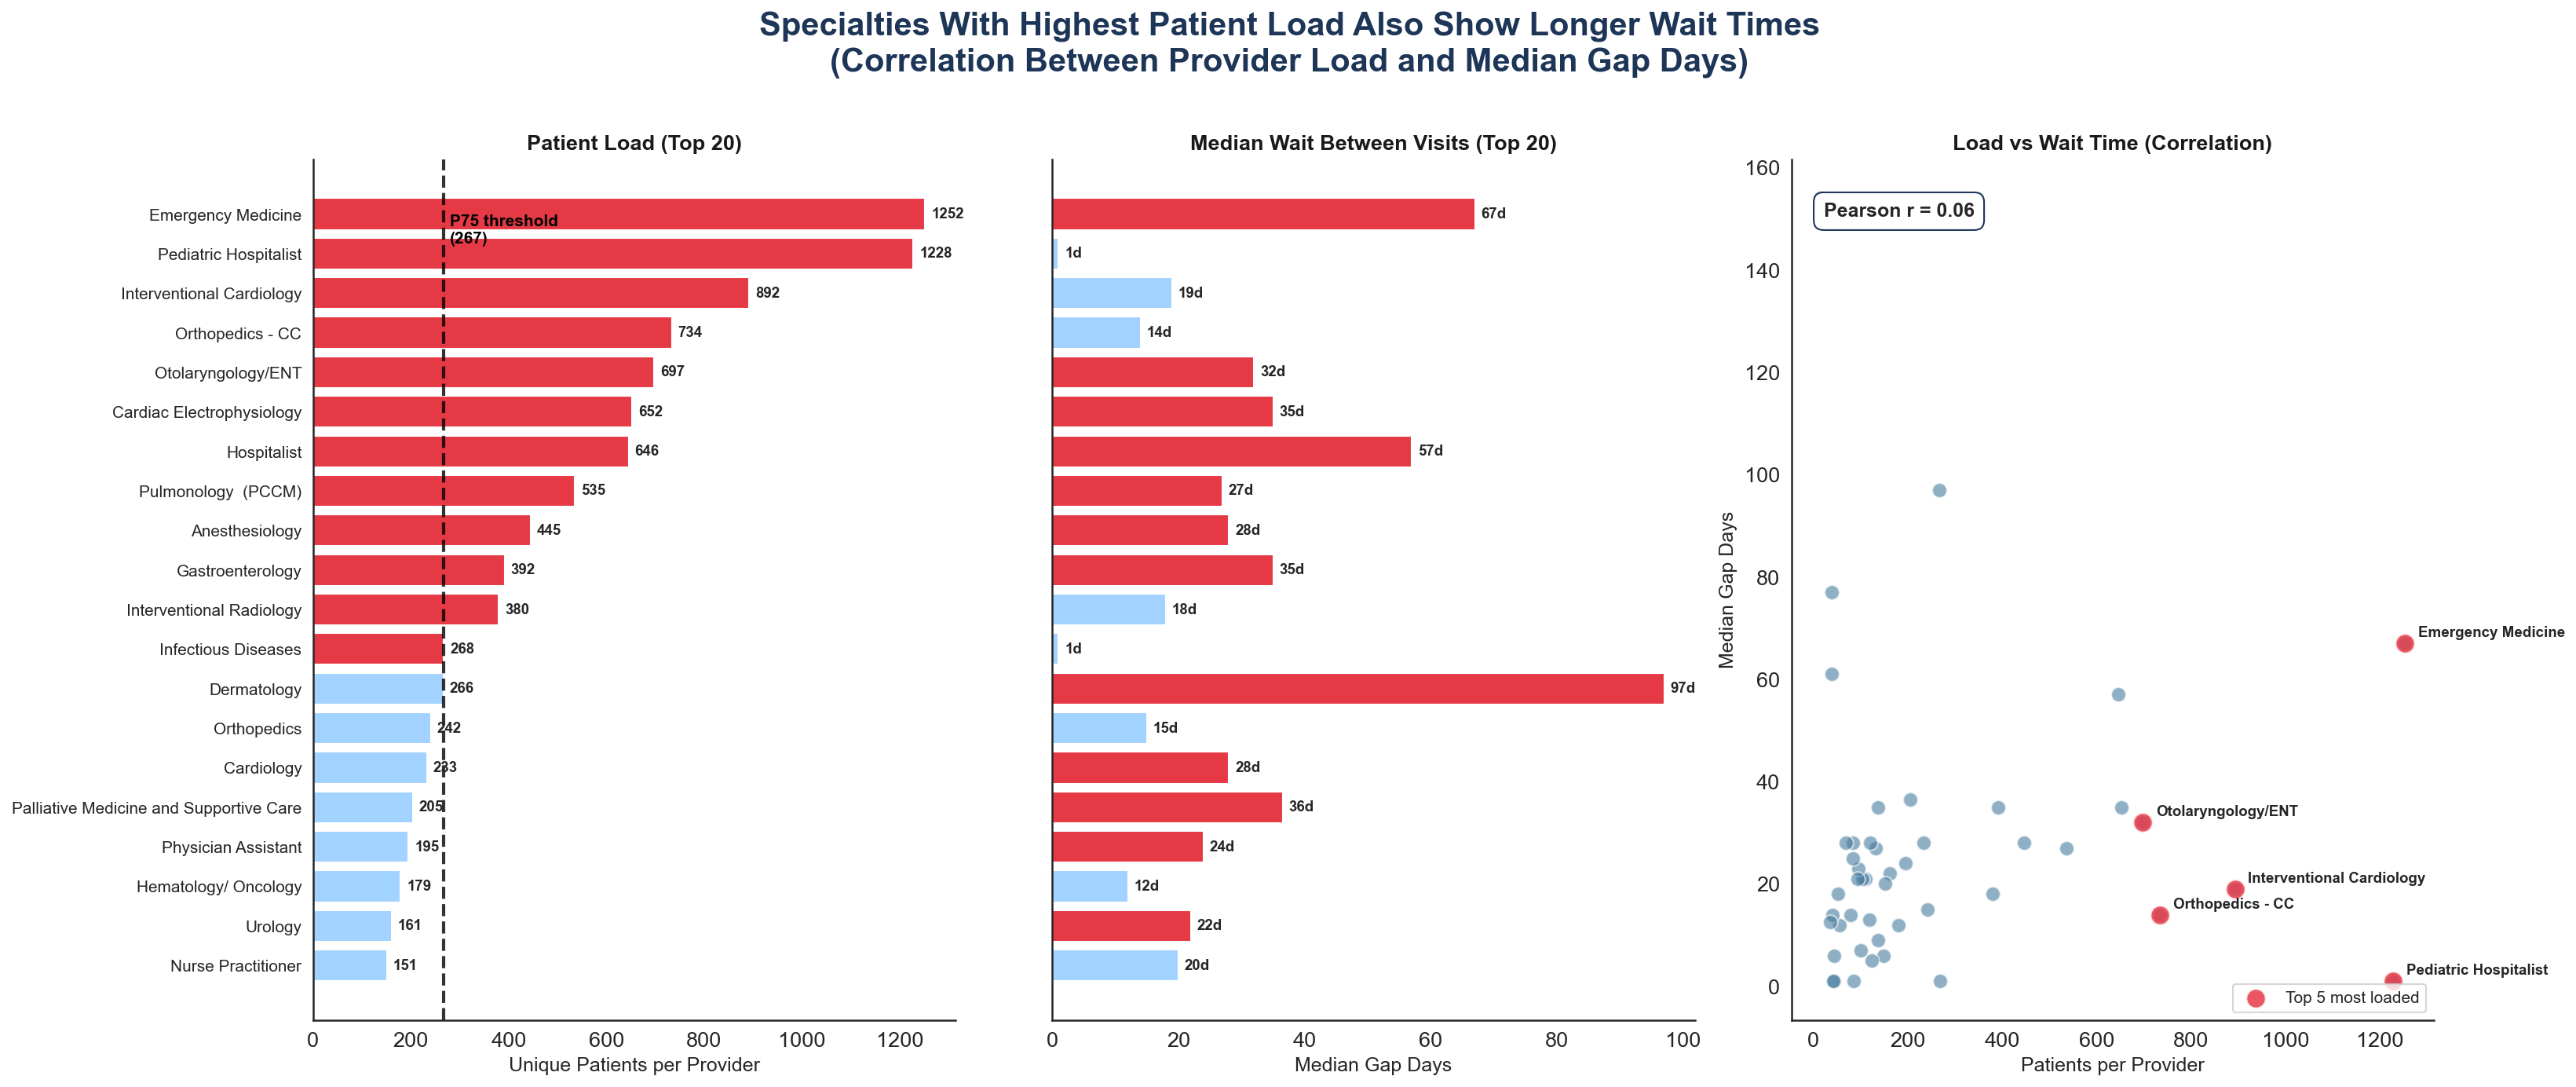

In [15]:
C_SOFT_BLUE = "#a2d2ff"
C_HIGHLIGHT = "#e63946"

top20 = load_df.sort_values("PatPerProvider", ascending=False).head(20)

# 3 subplots: bar chart of load, bar of median gap, scatter showing correlation
fig, axes = plt.subplots(1, 3, figsize=(22, 9))
fig.patch.set_facecolor("white")
fig.suptitle(
    "Specialties With Highest Patient Load Also Show Longer Wait Times\n"
    "(Correlation Between Provider Load and Median Gap Days)",
    fontsize=20, fontweight="bold", y=1.02, color="#1d3557"
)

# A. Bar chart: Patient-to-provider ratio
ax = axes[0]
y   = np.arange(len(top20))
c20 = [C_HIGHLIGHT if v >= BOTTLENECK_THRESH else C_SOFT_BLUE for v in top20["PatPerProvider"]]
bars = ax.barh(y[::-1],
               top20["PatPerProvider"],
               color=c20,
               edgecolor="white")
ax.set_yticks(y[::-1]); ax.set_yticklabels(top20["PrimarySpecialty"], fontsize=10)
ax.axvline(BOTTLENECK_THRESH, color="black", linestyle="--", lw=2, alpha=0.8)
ax.text(BOTTLENECK_THRESH + top20["PatPerProvider"].max()*0.01, len(top20)-1,
        f"P75 threshold\n({BOTTLENECK_THRESH:.0f})",
        color="black", fontsize=10, fontweight="bold", va="top")
for b in bars:
    ax.text(b.get_width() + top20["PatPerProvider"].max()*0.01,
            b.get_y()+b.get_height()/2,
            f"{b.get_width():.0f}",
            va="center", fontsize=9, fontweight="bold")
ax.set_xlabel("Unique Patients per Provider", fontsize=12)
ax.set_title("Patient Load (Top 20)", fontsize=13, fontweight="bold")
for sp in ["top","right"]: ax.spines[sp].set_visible(False)

# B. Bar chart: Median gap days for same top 20
ax = axes[1]
gap_vals = top20["MedianGap"].fillna(0).values
c_gap = [C_HIGHLIGHT if v >= np.nanmedian(load_df["MedianGap"]) else C_SOFT_BLUE for v in gap_vals]
bars2 = ax.barh(y[::-1], gap_vals, color=c_gap, edgecolor="white")
ax.set_yticks(y[::-1]); ax.set_yticklabels([])
for b, v in zip(bars2, gap_vals):
    ax.text(b.get_width() + max(gap_vals)*0.01, b.get_y()+b.get_height()/2,
            f"{v:.0f}d", va="center", fontsize=9, fontweight="bold")
ax.set_xlabel("Median Gap Days", fontsize=12)
ax.set_title("Median Wait Between Visits (Top 20)", fontsize=13, fontweight="bold")
for sp in ["top","right"]: ax.spines[sp].set_visible(False)

# C. Scatter showing correlation
ax = axes[2]
scatter_data = load_df.dropna(subset=["MedianGap"]).copy()
ax.scatter(scatter_data["PatPerProvider"], scatter_data["MedianGap"],
           s=80, alpha=0.6, color=C_OUT, edgecolor="white", linewidth=1)
# Highlight top 5 most loaded
top5_load = scatter_data.nlargest(5, "PatPerProvider")
ax.scatter(top5_load["PatPerProvider"], top5_load["MedianGap"],
           s=150, alpha=0.85, color=C_ED, edgecolor="white", linewidth=1.5,
           label="Top 5 most loaded")
for _, row in top5_load.iterrows():
    ax.annotate(row["PrimarySpecialty"],
                xy=(row["PatPerProvider"], row["MedianGap"]),
                xytext=(8, 4), textcoords="offset points",
                fontsize=9, fontweight="bold")

# Correlation coefficient
corr = scatter_data["PatPerProvider"].corr(scatter_data["MedianGap"])
ax.text(0.05, 0.95, f"Pearson r = {corr:.2f}",
        transform=ax.transAxes, fontsize=12, fontweight="bold",
        verticalalignment="top",
        bbox=dict(boxstyle="round,pad=0.5", facecolor="white", edgecolor="#1d3557"))

ax.set_xlabel("Patients per Provider", fontsize=12)
ax.set_ylabel("Median Gap Days", fontsize=12)
ax.set_title("Load vs Wait Time (Correlation)", fontsize=13, fontweight="bold")
ax.legend(loc="lower right", fontsize=10)
for sp in ["top","right"]: ax.spines[sp].set_visible(False)

plt.tight_layout()
savefig(fig, "B3_01_provider_load")

### 3.2 Where Exactly Does the System Stall?


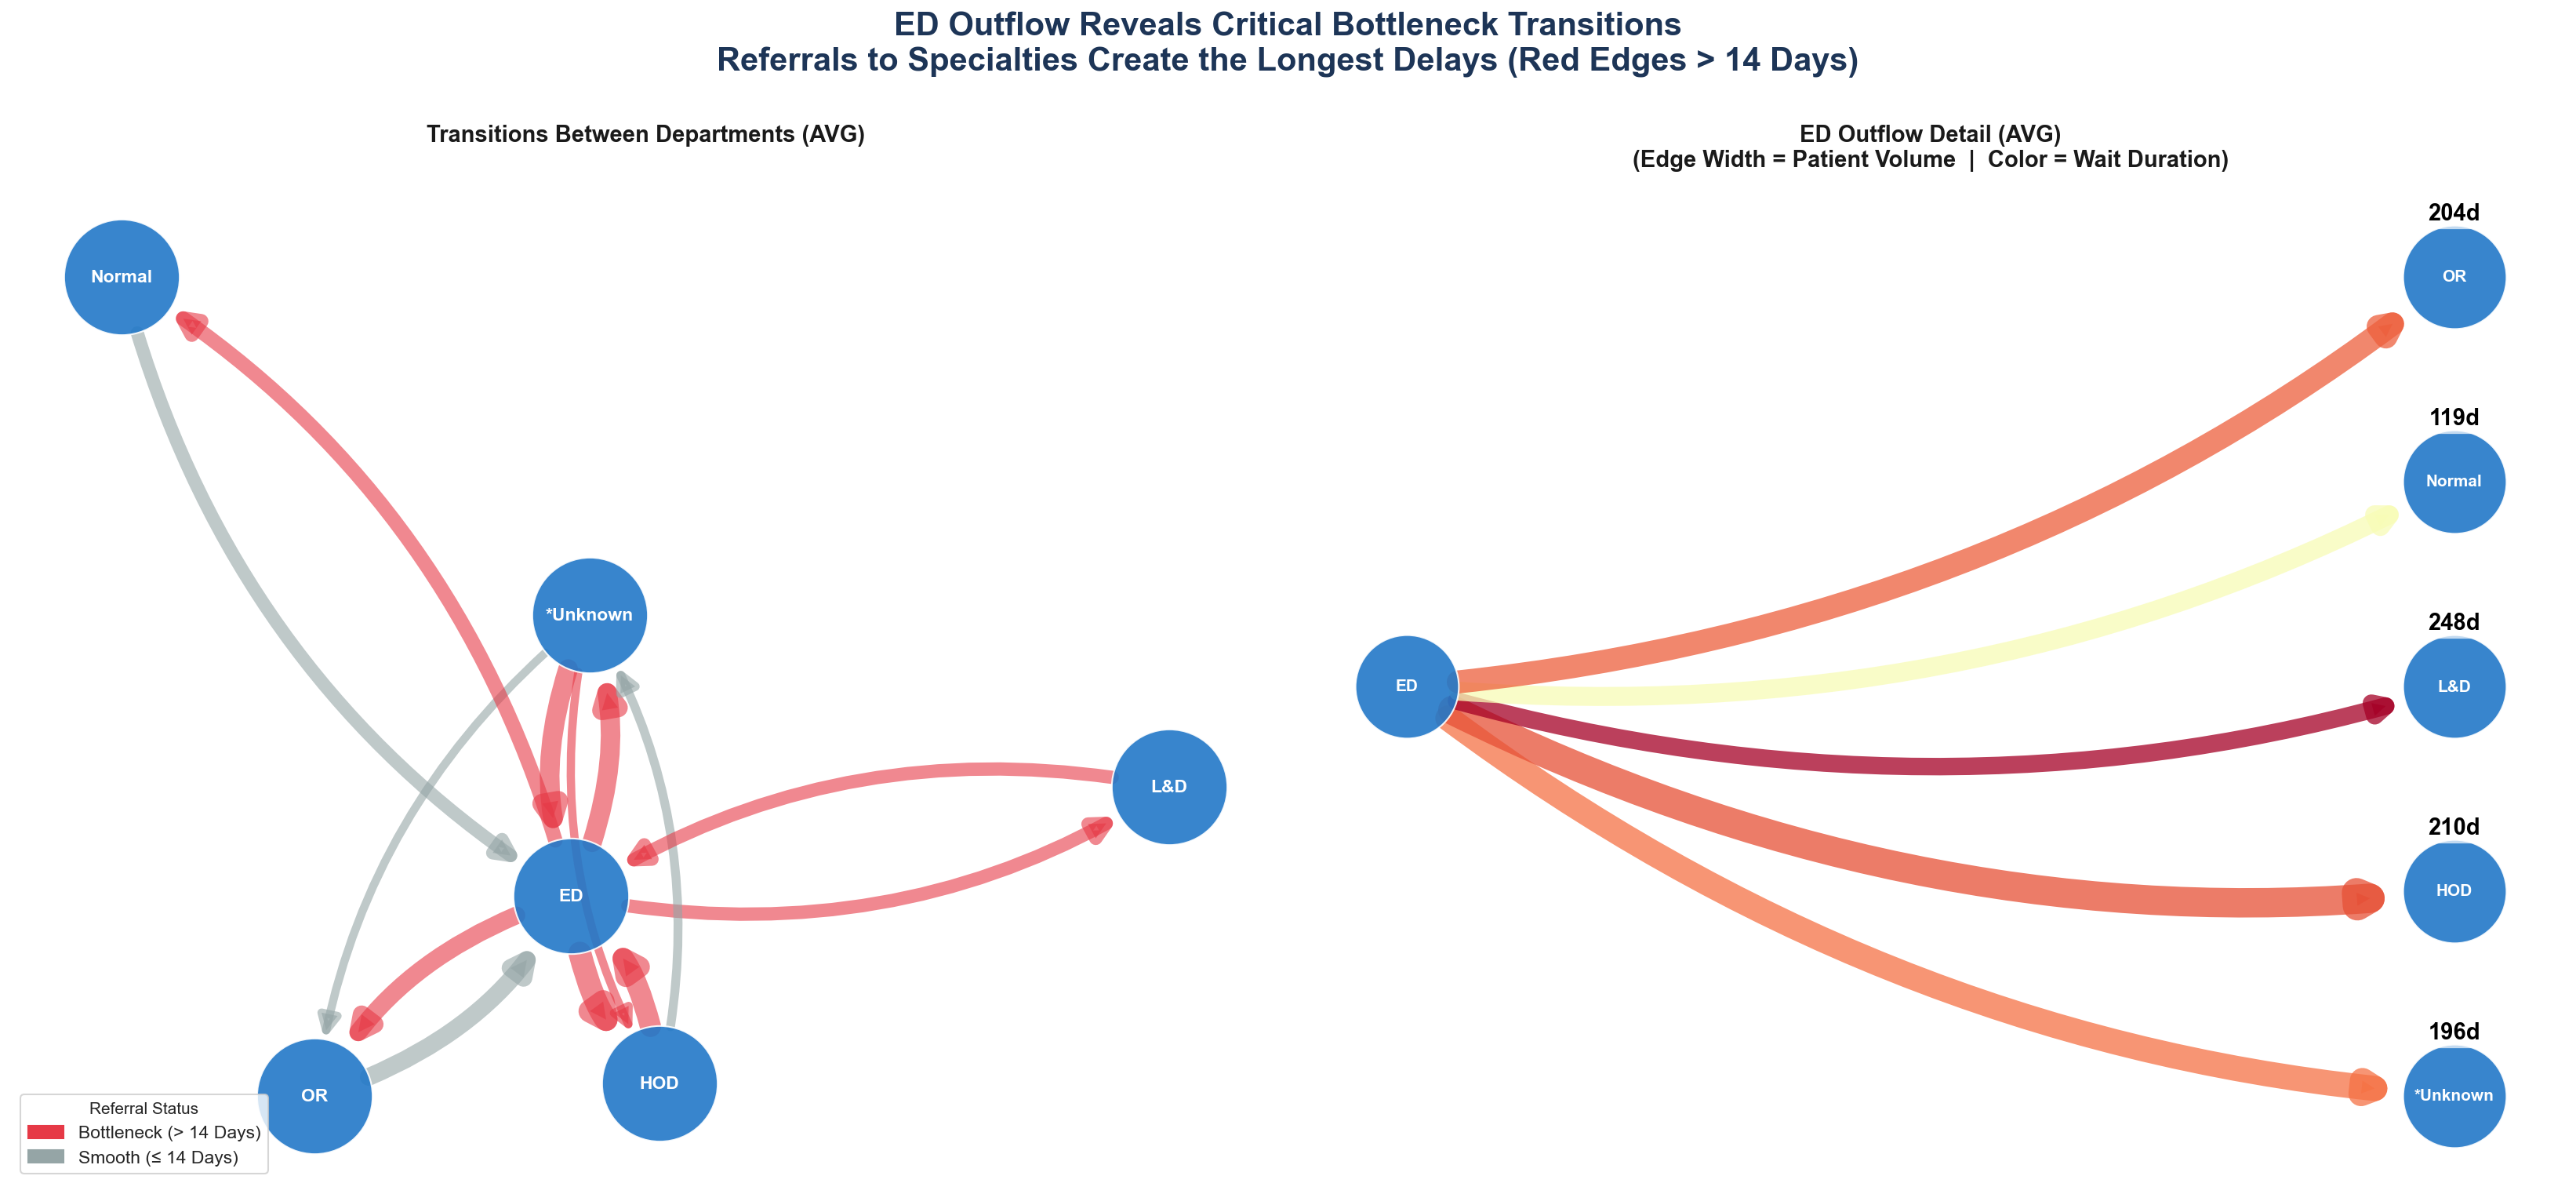

In [16]:
target_spec = "Emergency Medicine"
df_em = (enc_full[enc_full["PrimarySpecialty"] == target_spec]
         .sort_values(["PatientDurableKey","Date"]).copy())
df_em["NextDept"] = df_em.groupby("PatientDurableKey")["DepartmentType"].shift(-1)

sankey_data = (df_em.dropna(subset=["NextDept"])
               .groupby(["DepartmentType","NextDept"])
               .agg(Volume=("PatientDurableKey","count"),
                    AvgGap=("GapDays","mean"))
               .reset_index()
               .query("Volume > 5"))

if not sankey_data.empty:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 10))
    fig.patch.set_facecolor("white")
    fig.suptitle(
        "ED Outflow Reveals Critical Bottleneck Transitions\n"
        "Referrals to Specialties Create the Longest Delays (Red Edges > 14 Days)",
        fontsize=20, fontweight="bold", y=1.01, color="#1d3557"
    )

    # Macro flow
    G1 = nx.DiGraph()
    for _, row in sankey_data.iterrows():
        if row["DepartmentType"] != row["NextDept"]:
            G1.add_edge(row["DepartmentType"], 
                        row["NextDept"],
                        weight=row["Volume"], 
                        avg_gap=row["AvgGap"])

    if len(G1.nodes) > 0:
        pos1    = nx.spring_layout(G1, k=3.5, seed=42)
        volumes1= np.array([G1[u][v]["weight"] for u,v in G1.edges()])
        widths1 = 2 + (np.log1p(volumes1) / np.log1p(volumes1.max()+1) * 12)
        colors1 = [C_ED if G1[u][v]["avg_gap"] > 14 else "#95a5a6" for u,v in G1.edges()]

        nx.draw_networkx_nodes(G1, pos1, ax=ax1, node_size=5000,
                               node_color="#2278c8", edgecolors="white", alpha=0.9)
        nx.draw_networkx_labels(G1, pos1, ax=ax1, font_size=11,
                                font_weight="bold", font_color="white")
        nx.draw_networkx_edges(G1, pos1, ax=ax1, width=widths1, edge_color=colors1,
                               arrowstyle="-|>", arrowsize=25,
                               connectionstyle="arc3, rad=0.2", alpha=0.6,
                               node_size=5000)
    ax1.set_title("Transitions Between Departments (AVG)\n",
                  fontsize=14, fontweight="bold", pad=15)
    ax1.axis("off")
    ax1.legend(handles=[mpatches.Patch(color=C_ED, label="Bottleneck (> 14 Days)"),
                         mpatches.Patch(color="#95a5a6",label="Smooth (≤ 14 Days)")],
               loc="lower left", 
               title="Referral Status", 
               fontsize=11)

    # ED outflow micro
    outflow = sankey_data[(sankey_data["DepartmentType"]=="ED") &
                           (sankey_data["NextDept"]!="ED")].copy()

    G2 = nx.DiGraph()
    for _, row in outflow.iterrows():
        G2.add_edge(row["DepartmentType"], 
                    row["NextDept"],
                    weight=row["Volume"], 
                    avg_gap=row["AvgGap"])

    if len(G2.nodes) > 1:
        nodes_target = [n for n in G2.nodes() if n != "ED"]
        pos2 = {n: (1, i/(max(len(nodes_target)-1,1))) for i,n in enumerate(nodes_target)}
        pos2["ED"] = (0, 0.5)

        volumes2 = np.array([G2[u][v]["weight"] for u,v in G2.edges()])
        widths2  = 3 + (np.log1p(volumes2) / np.log1p(volumes2.max()+1) * 15)
        max_gap  = max(G2[u][v]["avg_gap"] for u,v in G2.edges())
        edge_colors2 = [plt.cm.RdYlGn_r(G2[u][v]["avg_gap"]/max(max_gap,1))
                        for u,v in G2.edges()]

        nx.draw_networkx_nodes(G2, pos2, ax=ax2, node_size=4000,
                               node_color="#2278c8", edgecolors="white", alpha=0.9)
        nx.draw_networkx_labels(G2, pos2, ax=ax2, font_size=10,
                                font_weight="bold", font_color="white")
        nx.draw_networkx_edges(G2, pos2, ax=ax2, width=widths2,
                               edge_color=edge_colors2, arrowstyle="-|>",
                               arrowsize=20, connectionstyle="arc3,rad=0.15", alpha=0.75,
                               node_size=4000)
        for u,v in G2.edges():
            x_target = pos2[v][0]
            y_target = pos2[v][1]
            
            y_text = y_target + 0.07
            ax2.text(x_target, y_text, f"{G2[u][v]['avg_gap']:.0f}d",
                     fontsize=14, ha="center", color="black", fontweight="bold",
                     bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.7))
    ax2.set_title("ED Outflow Detail (AVG)\n(Edge Width = Patient Volume  |  Color = Wait Duration)",
                  fontsize=14, fontweight="bold", pad=15)
    ax2.axis("off")

    plt.tight_layout()
    savefig(fig, "B3_03_network_journey_EM")


### 3.3 Gap Distribution in the Most Overloaded Specialties


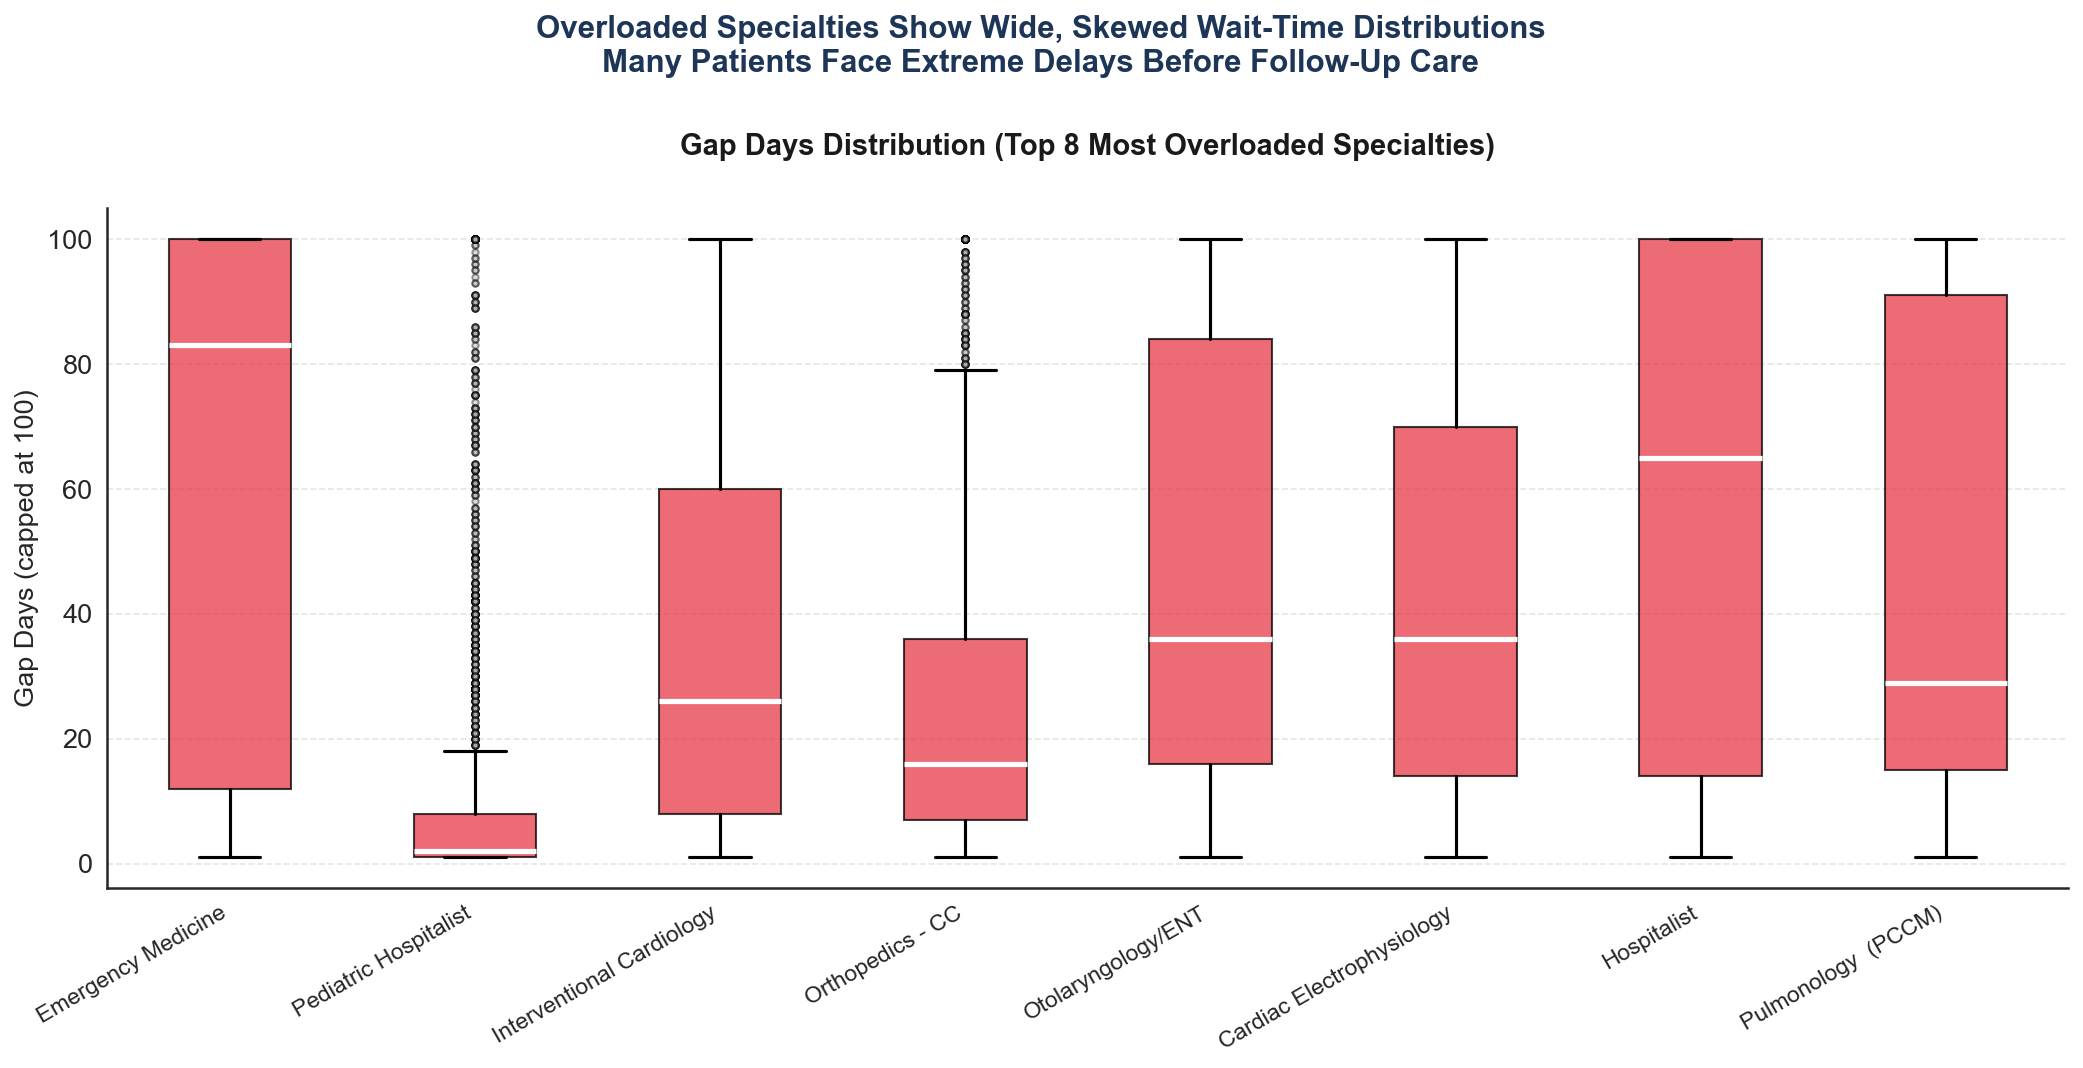

In [17]:
top_spec = load_df.nlargest(8, "PatPerProvider")["PrimarySpecialty"].tolist()
enc_bot  = enc_hv[enc_hv["PrimarySpecialty"].isin(top_spec)].dropna(subset=["GapDays"])
enc_bot  = enc_bot[enc_bot["GapDays"] > 0]

data_v = [enc_bot[enc_bot["PrimarySpecialty"] == sp]["GapDays"].clip(upper=100).values
          for sp in top_spec]

fig, ax = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor("white")
fig.suptitle(
    "Overloaded Specialties Show Wide, Skewed Wait-Time Distributions\n"
    "Many Patients Face Extreme Delays Before Follow-Up Care",
    fontsize=15, fontweight="bold", y=1.01, color="#1d3557"
)

box = ax.boxplot(data_v, positions=range(len(top_spec)),
                 patch_artist=True, notch=False,
                 medianprops=dict(color="white", linewidth=2.5),
                 flierprops=dict(marker="o", markerfacecolor="#aaa", markersize=3, alpha=0.4),
                 whiskerprops=dict(linewidth=1.5),
                 capprops=dict(linewidth=1.5))

for patch in box["boxes"]:
    patch.set_facecolor(C_ED)
    patch.set_alpha(0.75)

ax.set_xticks(range(len(top_spec)))
ax.set_xticklabels(top_spec, rotation=30, ha="right", fontsize=11)
ax.set_ylabel("Gap Days (capped at 100)", fontsize=13)
ax.set_title("Gap Days Distribution (Top 8 Most Overloaded Specialties)\n",
             fontweight="bold", fontsize=14, pad=10)

ax.yaxis.grid(True, linestyle="--", alpha=0.5, color="#cccccc")
ax.set_axisbelow(True)
for sp in ["top","right"]: ax.spines[sp].set_visible(False)

plt.tight_layout()
savefig(fig, "B3_04_bottleneck_gap_boxplot")
